# Vechicle Sale Price Prediction

## Objective
The objective of this project is to predict vehicle sale prices ( Sold_Amount) using machine learning techniques. This notebook documents the complete 
worflow including data understanding, preprocessing, feature engineering, model training, evaluation, and analysis.

## step 1 : Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 : Load the Training Dataset

### Objective
The first step is to load the training dataset into a pandas Dataframe. This dataset will be used for data understanding, feature engineering, model training, and evaluation.

In [5]:
# Load the training dataset
train_df = pd.read_csv("data/DatiumTrain.rpt",sep="\t", low_memory=False)

### Remove restricted Features

In [7]:
# List of restricted features provided in the project instructions
restricted_features = [
    'AvgWholesale',
    'AvgRetail',
    'GoodWholesale',
    'GoodRetail',
    'TradeMin',
    'TradeMax',
    'PrivateMax'
]
# Remove restricted features
train_df = train_df.drop(columns=restricted_features)

# Verify the updated dataset shape
print("Updated Dataset Shape:", train_df.shape)

Updated Dataset Shape: (50704, 123)


In [8]:
train_df.head()

,Make,Model,MakeCode,FamilyCode,YearGroup,MonthGroup,SequenceNum,Description,CurrentRelease,ImportFlag,...,GoodKM,NewPrice,Colour,Branch,SaleCategory,Sold_Date,Compliance_Date,Age_Comp_Months,KM,Sold_Amount
0,Holden,Commodore,HOLD,COMMODO,2008,0,0,VE Omega Sedan 4dr. Auto 4sp 3.6i,F,L,...,140.0,34790.0,White,Perth (WA),Auction,2015-11-03 00:00:00.000,02/2008,93.0,227878.0,2000.0
1,Holden,Commodore,HOLD,COMMODO,1993,7,41,VR Executive Wagon 5dr. Auto 4sp 3.8i,F,L,...,360.0,27978.0,Red,Belmore (NSW),Auction,2000-10-18 00:00:00.000,08/1993,86.0,153091.0,6800.0
2,Toyota,RAV4,TOYO,RAV4,2012,0,6,ACA33R MY12 CV Wagon 5dr Man 5sp 4x4 2.4i,F,L,...,80.0,31990.0,040 - Glacier White (T),Sunshine (VIC),Dealer Only Auction,2014-02-05 00:00:00.000,10/2012,16.0,27374.0,22900.0
3,Holden,Commodore,HOLD,COMMODO,2007,0,11,VZ@VE MY07 Executive Wagon 5dr. Auto 4sp 3.6i,F,L,...,150.0,35990.0,Quicksilver,Belmore (NSW),Auction,2011-01-10 00:00:00.000,01/2007,48.0,99452.0,10500.0
4,Toyota,Tarago,TOYO,TARAGO,2007,0,0,ACR50R GLi Wagon 8st 5dr Spts Auto 4sp 2.4i,F,L,...,150.0,49490.0,Silver,Hobart (TAS),Special Fixed Price,2009-05-23 00:00:00.000,01/2007,28.0,44355.0,31320.0


#### Analysis & Observation


The training dataset was successfully loaded into a Pandas DataFrame. The initial inspection indicates that each row represents an individual vehicle record containing a combination of vehicle characteristics, pricing information, and sale-related details. The target variable (`Sold_Amount`) is also present, . As of now it displays only a few columns, the remaining columns will be explored in the subsequent EDA steps to understand their meaning, assess their quality, and determine their relevance for model development.

## Step 3: Data Understanding ( EDA )
### 3.1 Dataset Shape
#### Objective
before exploring the dataset, it is important to understand the dimensions.This helps us identify number of rows and columns are available for analysis.

In [11]:
train_df.shape

(50704, 123)

### Observation
The training dataset contains **50,704 rows** and **123 columns**.Each row represents a vehicle record, and each column represents a feature describing the vehicle or the target variable ('Sold_Amount').

#### 3.2 Dataset Information

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50704 entries, 0 to 50703
Columns: 123 entries, Make to Sold_Amount
dtypes: float64(58), int64(6), object(59)
memory usage: 47.6+ MB


### observation
The dataset contains a combination of numerical and categorical features. Numerical columns (float and integer) will be used for statistical analysis and model training, while categorical (object) columns will require encoding before they can be used by most machine learning algorithms.

### 3.3 Missing Values Analysis
#### Objective
Identifying the missing values in the dataset to evaluate data quality.

In [17]:
train_df.isnull().sum()

Make                0
Model               0
MakeCode            0
FamilyCode          0
YearGroup           0
                   ..
Sold_Date           1
Compliance_Date    45
Age_Comp_Months    45
KM                  2
Sold_Amount         4
Length: 123, dtype: int64

In [18]:
train_df.isnull().sum().sort_values(ascending=False)

NormalChargeMins           50704
AltEngTorqueFrom           50704
QuickChargeMins            50704
NormalChargeVoltage        50704
QuickChargeVoltage         50704
                           ...  
InductionDescription           0
OptionCategory                 0
EngineTypeDescription          0
FuelDeliveryDescription        0
Make                           0
Length: 123, dtype: int64

### Analysis & Observation

The missing value analysis reveals that several features contain missing values. A few columns have missing values for every record (100% missing), indicating that they currently provide no usable information. These features will be evaluated to determine whether they should be excluded from the analysis. Columns with only a small number of missing values will be handled using an appropriate preprocessing strategy to preserve as much useful information as possible.

In [20]:
#checking the count for 100% missing values
(train_df.isnull().sum() == len(train_df)).sum()

5

In [21]:
null_columns = train_df.columns[train_df.isnull().sum() == len(train_df)]
null_columns

Index(['AltEngTorqueFrom', 'NormalChargeMins', 'QuickChargeMins',
       'NormalChargeVoltage', 'QuickChargeVoltage'],
      dtype='object')

### Analysis & Observation

The missing value analysis identified **5 features** with 100% missing values, indicating that these features contain no data across all 50,704 records. Since these columns do not provide any information for analysis or prediction, they will be removed during the data cleaning procesy.

In [23]:
# removing columns with 100% missing values
train_df = train_df.drop(columns=null_columns) 

In [24]:
train_df.shape

(50704, 118)

In [25]:
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

KMRangeElectricEng        50702
TopSpeedElectricEng       50702
AltEngAmpHours            50698
ElectricEngineLocation    50678
FreeScheduledService      50608
                          ...  
Branch                        1
NewPrice                      1
GoodKM                        1
GearNum                       1
AverageKM                     1
Length: 93, dtype: int64

In [26]:
# Calculate the percentage of missing values for each feature
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

missing_percent.head(20)

KMRangeElectricEng        99.996056
TopSpeedElectricEng       99.996056
AltEngAmpHours            99.988167
ElectricEngineLocation    99.948722
FreeScheduledService      99.810666
AltEngPowerFrom           99.692332
AltEngTorqueTo            99.676554
PowerRPMFrom              99.587804
AltEngPowerTo             99.532581
Roofline                  98.974440
AltEngTorque              98.451799
AltEngDrive               98.353187
AltEngPower               98.351215
AltEngVolts               98.351215
AltEngEngineType          98.347270
AltEngCurrentType         98.347270
AltEngChargingMethod      98.347270
AltEngBatteryType         98.347270
WheelBaseConfig           96.451956
MaxEthanolBlend           95.864232
dtype: float64

In [27]:
# Count the number of features with more than 90% missing values
columns_to_drop = missing_percent[missing_percent > 90].index

len(columns_to_drop)

23

In [28]:
# Remove features with more than 90% missing values
train_df = train_df.drop(columns=columns_to_drop)

In [29]:
train_df.shape

(50704, 95)

In [30]:
#How many columns still have missing values after our cleaning
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

BodyConfigDescription            42021
EmissionStandard                 41755
CO2ExtraUrban                    38594
CO2Urban                         38592
Acceleration                     35574
                                 ...  
GoodKM                               1
NewPrice                             1
SaleCategory                         1
Sold_Date                            1
BuildCountryOriginDescription        1
Length: 70, dtype: int64

In [31]:
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100

missing_percent[(missing_percent > 0) & (missing_percent <= 90)].sort_values(ascending=False)

BodyConfigDescription            82.875118
EmissionStandard                 82.350505
CO2ExtraUrban                    76.116283
CO2Urban                         76.112338
Acceleration                     70.160145
                                   ...    
SaleCategory                      0.001972
Sold_Date                         0.001972
EngineCycleDescription            0.001972
BuildCountryOriginDescription     0.001972
AverageKM                         0.001972
Length: 70, dtype: float64

In [32]:
# Count features based on missing value percentage ranges

print("70% - 90% :", ((missing_percent > 70) & (missing_percent <= 90)).sum())
print("50% - 70% :", ((missing_percent > 50) & (missing_percent <= 70)).sum())
print("30% - 50% :", ((missing_percent > 30) & (missing_percent <= 50)).sum())
print("10% - 30% :", ((missing_percent > 10) & (missing_percent <= 30)).sum())
print("0% - 10%  :", ((missing_percent > 0) & (missing_percent <= 10)).sum())

70% - 90% : 5
50% - 70% : 6
30% - 50% : 9
10% - 30% : 6
0% - 10%  : 44


### Analysis & Observation

The missing value analysis revealed different levels of missingness across the dataset. Initially, five features containing 100% missing values and twenty-three features with more than 90% missing values were removed, as they provided little to no useful informatiog values.

These results indicate that the remaining missing values vary considerably across features. Therefore, a single imputation strategy would not be appropriate. The remaining missing values will be handled using feature-specific preprocessing techniques based on the percentage of missing values, data type, and business relevance.

### 3.4 Duplicate Records Analysis

#### Objective

Identify duplicate records in the dataset to ensure that each observation is unique and to prevent duplicate entries from affecting the analysis and machine learning model.

In [35]:
# Check the number of duplicate records
train_df.duplicated().sum()

0

#### Analysis & Observation

The duplicate record analysis found **no duplicate records** in the dataset. This indicates that each row represents a unique vehicle record, reducing the risk of biased learning caused by repeated observations. Since no duplicate entries were identified, no duplicate removal was required.

### 3.5 Data Type Analysis

#### Objective

Examine the data types of all features to identify numerical, categorical, and date-related attributes, and detect any incorrect or inconsistent data types that may affect data analysis and model performance.

In [38]:
train_df.dtypes

Make                object
Model               object
MakeCode            object
FamilyCode          object
YearGroup            int64
                    ...   
Sold_Date           object
Compliance_Date     object
Age_Comp_Months    float64
KM                 float64
Sold_Amount        float64
Length: 95, dtype: object

### 3.6 Statistical Summary

#### Objective

Generate summary statistics for numerical features to understand their central tendency, spread, and overall distribution. This helps identify unusual values, potential outliers, and inconsistencies in the dataset.

In [40]:
# Generate summary statistics for numerical features
train_df.describe()

,YearGroup,MonthGroup,SequenceNum,GearNum,DoorNum,EngineSize,Cylinders,FuelCapacity,GrossCombinationMAss,GrossVehicleMass,...,FuelUrban,FuelExtraurban,FuelCombined,AncapRating,AverageKM,GoodKM,NewPrice,Age_Comp_Months,KM,Sold_Amount
count,50704.000000,50704.000000,50704.000000,50703.000000,50704.000000,50704.000000,50704.000000,49892.000000,24524.000000,30463.000000,...,29394.000000,28241.000000,46346.000000,25965.000000,50703.000000,50703.000000,50703.000000,50659.000000,5.070200e+04,50700.000000
mean,2005.177777,1.480396,9.632869,4.615447,4.124467,3000.569580,5.061731,71.905035,4237.271489,2353.787874,...,11.587654,7.170908,9.476818,4.260312,306.617163,188.857168,36726.014555,45.775223,8.495406e+04,16401.722226
std,5.302207,2.997782,11.171761,0.956656,0.868757,931.057061,1.123823,22.131647,1090.250085,506.228417,...,2.642395,1.392198,2.102242,0.654834,139.121984,88.032477,15522.567237,32.153830,7.283732e+04,10312.029249
min,1968.000000,0.000000,0.000000,1.000000,2.000000,659.000000,2.000000,32.000000,1450.000000,970.000000,...,3.700000,3.700000,3.900000,1.000000,35.000000,20.000000,5157.000000,0.000000,0.000000e+00,0.000000
25%,2001.000000,0.000000,1.000000,4.000000,4.000000,2359.000000,4.000000,63.000000,3310.000000,1990.000000,...,10.200000,6.500000,8.200000,4.000000,200.000000,120.000000,29500.000000,26.000000,4.085400e+04,10500.000000
50%,2006.000000,0.000000,6.000000,4.000000,4.000000,2982.000000,5.000000,70.000000,4140.000000,2220.000000,...,11.500000,7.000000,9.200000,4.000000,275.000000,180.000000,34990.000000,38.000000,6.846900e+04,15000.000000
75%,2009.000000,1.000000,15.000000,5.000000,5.000000,3791.000000,6.000000,75.000000,4900.000000,2800.000000,...,12.500000,7.800000,10.900000,5.000000,400.000000,240.000000,41260.000000,54.000000,1.165400e+05,20425.000000
max,2016.000000,12.000000,120.000000,9.000000,5.000000,7300.000000,12.000000,180.000000,9071.000000,5670.000000,...,29.100000,16.000000,19.500000,5.000000,1170.000000,780.000000,525000.000000,1279.000000,8.883234e+06,317000.000000


#### Analysis & ObservationThe statistical summary shows that some variables contain zero values, while others have very large maximum values compared with their typical values. These values may indicate valid cases or possible data quality issues, so I will investigate them further during data cleaning and preprocessing.

### 3.7 Categorical Features Analysis

#### Objective

Examine the categorical features to understand the types of categories present in the dataset and identify any features with a large number of unique values or potential data quality issues.

In [43]:
# Display summary statistics for categorical features
train_df.describe(include='object')

,Make,Model,MakeCode,FamilyCode,Description,CurrentRelease,ImportFlag,LimitedEdition,Series,SeriesModelYear,...,EmissionStandard,VFactsClass,VFactsSegment,VFactsPrice,IsPPlateApproved,Colour,Branch,SaleCategory,Sold_Date,Compliance_Date
count,50704,50704,50704,50704,50704,50704,50704,50704,49853,15540,...,8949,50276,50276,40323,50703,50660,50703,50703,50703,50659
unique,52,582,52,581,8568,1,1,2,1034,46,...,5,4,13,17,2,905,18,6,4747,404
top,Toyota,Commodore,TOYO,COMMODO,ACV40R Altise Sedan 4dr Auto 5sp 2.4i,F,L,F,VE,MY10,...,Euro 4,Passenger,Large,< $70K,T,White,Belmore (NSW),Auction,2015-07-01 00:00:00.000,06/2010
freq,15720,6827,15720,6827,707,50704,50704,49893,1713,3605,...,5458,31672,20267,19376,48580,15738,15188,38804,62,431


#### Analysis & Observation
The categorical features contain different numbers of categories. Some features have only a few categories, while others have many different categories, which may require careful encoding during data preprocessing. The summary also shows that some categorical features contain missing values. These observations indicate that suitable encoding methods and missing value handling will be required before model training.e.s.

## 3.8 Outlier Analysis

### Objective

Identify potential outliers in important numerical features to determine whether unusually high or low values are present that may influence the machine learning model.

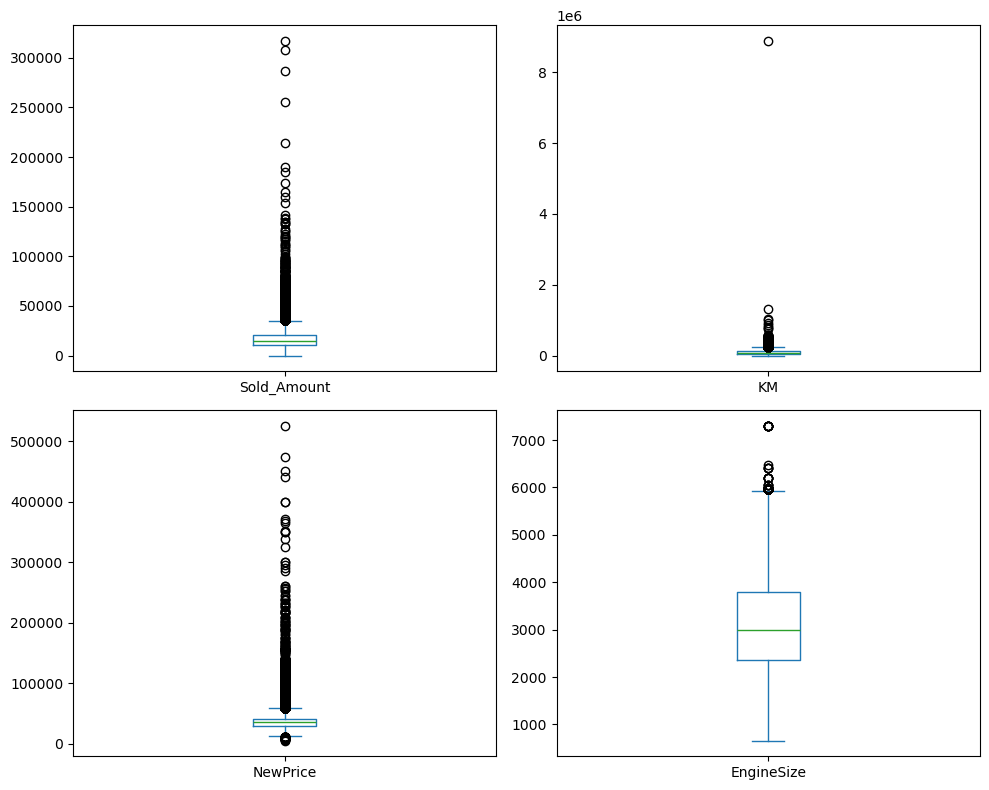

In [46]:
import matplotlib.pyplot as plt

# Select important numerical features
important_features = ['Sold_Amount', 'KM', 'NewPrice', 'EngineSize']

# Create boxplots
train_df[important_features].plot(
    kind='box',
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8)
)

plt.tight_layout()
plt.show()

#### Analysis & Observation

The boxplots show that the selected numerical features contain several outliers, especially in `Sold_Amount`, `KM`, and `NewPrice`. Before removing these values, it is important to determine whether they are genuine vehicle records or data entry errors. Since high-priced vehicles, high mileage, and larger engine sizes can occur in real-world data, these outliers will be reviewed during preprocessing before making any decision.

### 3.9 Correlation Analysis

#### Objective

Examine the relationship between numerical features to identify features that are strongly related to the target variable and detect highly correlated features that may affect the model.

In [49]:
# Correlation of numerical features with the target variable
target_correlation = train_df.corr(numeric_only=True)['Sold_Amount'].sort_values(ascending=False)

target_correlation

Sold_Amount               1.000000
NewPrice                  0.647975
KerbWeight                0.457344
TareMass                  0.448737
GrossCombinationMAss      0.380479
FuelCapacity              0.335492
Torque                    0.329744
TowingBrakes              0.308577
GrossVehicleMass          0.303661
Height                    0.285792
CO2ExtraUrban             0.247441
YearGroup                 0.240074
Power                     0.234858
RonRating                 0.229907
Width                     0.221081
TowingNoBrakes            0.197497
CO2Combined               0.195014
EngineSize                0.188039
SeatCapacity              0.175678
GearNum                   0.175163
Length                    0.173980
CO2Urban                  0.159091
WheelBase                 0.157476
Cylinders                 0.151605
FuelExtraurban            0.150387
FuelUrban                 0.141501
AncapRating               0.135553
FuelCombined              0.132174
FirstServiceKM      

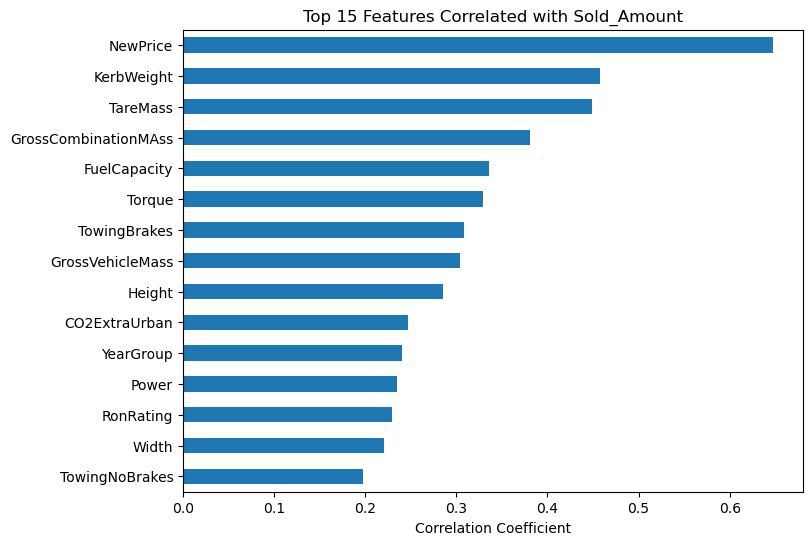

In [50]:
# Top 15 features most correlated with Sold_Amount
top_features = target_correlation.drop('Sold_Amount').sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')

plt.title("Top 15 Features Correlated with Sold_Amount")
plt.xlabel("Correlation Coefficient")
plt.show()

#### Analysis & Observation
The correlation analysis shows that some numerical features have a stronger relationship with Sold_Amount than others. Some vehicle pricing-related features show stronger positive correlations, while others have weak or negative correlations. I will use these results as one factor when making feature-selection decisions, together with missing values and other data-quality considerations.g.

## 3.10 EDA Summary
### Key Findings

- The dataset initially contained **130 features and 50,704 records**.
- The restricted features specified in the project instructions were removed before further analysis.
- Five features had **100% missing values**, and additional features had more than 90% missing values. These were removed because they provided little or no useful information.
- The remaining missing values vary across features and will be handled during preprocessing using appropriate techniques.
- No duplicate records were found in the dataset.
- The dataset contains both numerical and categorical features, requiring different preprocessing methods.
- Several numerical features contain potential outliers. These will be reviewed before deciding whether to retain or remove them.
- Correlation analysis showed that some features have stronger relationships with `Sold_Amount` and will be considered during feature selection. training.

## Section 4: Data Preprocessing

### 4.1 Missing Value Handling

### Objective

The objective of this step is to identify the remaining missing values in the dataset and apply appropriate imputation techniquee.

In [56]:
# Remaining missing values
missing_values = train_df.isnull().sum()

# Display only columns with missing values
remaining_missing = missing_values[missing_values > 0].sort_values(ascending=False)

print(remaining_missing)

BodyConfigDescription            42021
EmissionStandard                 41755
CO2ExtraUrban                    38594
CO2Urban                         38592
Acceleration                     35574
                                 ...  
SaleCategory                         1
Sold_Date                            1
EngineCycleDescription               1
BuildCountryOriginDescription        1
AverageKM                            1
Length: 70, dtype: int64


In [57]:
# Numerical features with missing values
num_missing = train_df.select_dtypes(include=['number']).isnull().sum()
num_missing = num_missing[num_missing > 0].sort_values(ascending=False)

print("Numerical Features with Missing Values")
print(num_missing)

print("-" * 50)

# Categorical features with missing values
cat_missing = train_df.select_dtypes(include=['object']).isnull().sum()
cat_missing = cat_missing[cat_missing > 0].sort_values(ascending=False)

print("Categorical Features with Missing Values")
print(cat_missing)

Numerical Features with Missing Values
CO2ExtraUrban             38594
CO2Urban                  38592
Acceleration              35574
GrossCombinationMAss      26180
AirpollutionRating        26074
GreenhouseRating          26060
OverallGreenStarRating    25883
PayLoad                   25089
AncapRating               24739
FirstServiceMonths        22813
FuelExtraurban            22463
FuelUrban                 21310
GrossVehicleMass          20241
FirstServiceKM            19972
RegServiceMonths          19958
CO2Combined               16974
RonRating                 10967
TareMass                  10551
TowingNoBrakes             5200
FuelCombined               4358
WarrantyKM                 2965
TowingBrakes               2944
WarrantyYears              2614
KerbWeight                 1534
FuelCapacity                812
Height                      719
Length                      659
Width                       657
ValvesCylinder              510
TorqueRPMTo                 308
T

In [58]:
# Remove rows where the target variable is missing
train_df = train_df.dropna(subset=['Sold_Amount'])

# Verify
print("Remaining missing values in Sold_Amount:", train_df['Sold_Amount'].isnull().sum())
print("Updated dataset shape:", train_df.shape)

Remaining missing values in Sold_Amount: 0
Updated dataset shape: (50700, 95)


In [59]:
train_df['Sold_Amount'].describe()

count     50700.000000
mean      16401.722226
std       10312.029249
min           0.000000
25%       10500.000000
50%       15000.000000
75%       20425.000000
max      317000.000000
Name: Sold_Amount, dtype: float64

In [60]:
(train_df['Sold_Amount'] == 0).sum()

734

In [61]:
# Sold_Amount = 0 is not a realistic sale price, likely bad/placeholder data — removing these rows
train_df = train_df[train_df['Sold_Amount'] > 0]

print("Updated dataset shape:", train_df.shape)

Updated dataset shape: (49966, 95)


### Observation

Found 734 rows where `Sold_Amount` was 0. A car cannot realistically sell for $0, so these are 
likely data entry errors, repossessions, or internal transfers rather than genuine market sales. 
These rows were removed to prevent the model from learning incorrect price patterns.

In [63]:
# Remove rows where KM is missing
# Drop rows with missing KM to avoid inaccurate mileage imputation.
train_df = train_df.dropna(subset=['KM'])

# Verify
print("Remaining missing values in KM:", train_df['KM'].isnull().sum())
print("Updated dataset shape:", train_df.shape)

Remaining missing values in KM: 0
Updated dataset shape: (49965, 95)


In [64]:
train_df[['GoodKM', 'NewPrice', 'AverageKM', 'GearNum']].isnull().sum()

GoodKM       0
NewPrice     0
AverageKM    0
GearNum      0
dtype: int64

In [65]:
# Calculate missing percentage for numerical features
num_missing_percent = (
    train_df.select_dtypes(include=['number'])
            .isnull()
            .mean() * 100
)

# Display only columns with missing values
num_missing_percent = num_missing_percent[num_missing_percent > 0].sort_values(ascending=False)

print(num_missing_percent)

CO2ExtraUrban             76.063244
CO2Urban                  76.059241
Acceleration              69.994996
AirpollutionRating        51.794256
GreenhouseRating          51.766236
GrossCombinationMAss      51.586110
OverallGreenStarRating    51.411988
PayLoad                   49.418593
AncapRating               49.192435
FirstServiceMonths        45.355749
FuelExtraurban            43.894726
FuelUrban                 41.597118
FirstServiceKM            39.791854
GrossVehicleMass          39.773842
RegServiceMonths          39.735815
CO2Combined               33.907735
RonRating                 21.561093
TareMass                  20.856600
TowingNoBrakes            10.213149
FuelCombined               8.692084
WarrantyKM                 5.928150
TowingBrakes               5.866106
WarrantyYears              5.229661
KerbWeight                 3.002101
FuelCapacity               1.625138
Height                     1.431002
Length                     1.312919
Width                      1

### Objective

The objective of this step is to evaluate numerical features with a high percentage of missing values before deciding whether to retain or remove them. Instead of relying only on the percentage of missing values, the relationship between these features and the target variable will also be considered.

In [67]:
# Numerical features with more than 50% missing values
high_missing_features = [
    'CO2ExtraUrban',
    'CO2Urban',
    'Acceleration',
    'GrossCombinationMAss',
    'AirpollutionRating',
    'GreenhouseRating',
    'OverallGreenStarRating'
]

In [68]:
# Correlation of high-missing features with Sold_Amount
high_missing_corr = (
    train_df[high_missing_features + ['Sold_Amount']]
    .corr(numeric_only=True)['Sold_Amount']
    .drop('Sold_Amount')
    .sort_values(key=abs, ascending=False)
)

print(high_missing_corr)

GrossCombinationMAss      0.396173
CO2ExtraUrban             0.260664
Acceleration             -0.232499
GreenhouseRating         -0.232319
OverallGreenStarRating   -0.220042
CO2Urban                  0.171984
AirpollutionRating       -0.167688
Name: Sold_Amount, dtype: float64


#### Analysis & Observation
The correlation analysis of the high-missing numerical features shows that their relationship with the target variable varies. GrossCombinationMass has the strongest positive correlation with Sold_Amount, while CO2ExtraUrban, Acceleration, GreenhouseRating, and OverallGreenStarRating show moderate relationships. In contrast, CO2Urban and AirpollutionRating have relatively weak correlations with the target variable. These findings, together with the percentage of missing values, will be considered before deciding whether to retain or remove these features.

In [70]:
# Drop numerical features with high missing values and weak correlation
train_df = train_df.drop(columns=['CO2Urban', 'AirpollutionRating'])

print(train_df.shape)

(49965, 93)


#### Analysis and observation
High-missing numerical features were evaluated using both their missing value percentage and their correlation with the target variable. This helped make informed decisions on whether to retain or remove each feature.

### 4.1.3 Handle Remaining Numerical Missing Values
### Objective

The objective of this step is to handle the remaining missing values in numerical features using an appropriate imputation technique. Median imputation is used because it is less affected by outliers and preserves the overall distribution of the data.

In [73]:
num_missing = train_df.select_dtypes(include=['number']).isnull().sum()
num_missing = num_missing[num_missing > 0].sort_values(ascending=False)

print(num_missing)

CO2ExtraUrban             38005
Acceleration              34973
GreenhouseRating          25865
GrossCombinationMAss      25775
OverallGreenStarRating    25688
PayLoad                   24692
AncapRating               24579
FirstServiceMonths        22662
FuelExtraurban            21932
FuelUrban                 20784
FirstServiceKM            19882
GrossVehicleMass          19873
RegServiceMonths          19854
CO2Combined               16942
RonRating                 10773
TareMass                  10421
TowingNoBrakes             5103
FuelCombined               4343
WarrantyKM                 2962
TowingBrakes               2931
WarrantyYears              2613
KerbWeight                 1500
FuelCapacity                812
Height                      715
Length                      656
Width                       654
ValvesCylinder              509
TorqueRPMTo                 307
Torque                      272
WheelBase                   143
PowerRPMTo                  137
Power   

#### Analysis & Observation

The remaining numerical features have varying levels of missing values, ranging from very low to high. Since these features contain outliers and are considered useful for prediction, median imputation was selected to handle the remaining missing values.

In [75]:
# Drop numerical features with extremely high missing values
train_df = train_df.drop(columns=['CO2ExtraUrban', 'Acceleration'])

print(train_df.shape)

(49965, 91)


In [76]:
num_missing = train_df.select_dtypes(include=['number']).isnull().sum()
num_missing = num_missing[num_missing > 0].sort_values(ascending=False)

print(num_missing)

GreenhouseRating          25865
GrossCombinationMAss      25775
OverallGreenStarRating    25688
PayLoad                   24692
AncapRating               24579
FirstServiceMonths        22662
FuelExtraurban            21932
FuelUrban                 20784
FirstServiceKM            19882
GrossVehicleMass          19873
RegServiceMonths          19854
CO2Combined               16942
RonRating                 10773
TareMass                  10421
TowingNoBrakes             5103
FuelCombined               4343
WarrantyKM                 2962
TowingBrakes               2931
WarrantyYears              2613
KerbWeight                 1500
FuelCapacity                812
Height                      715
Length                      656
Width                       654
ValvesCylinder              509
TorqueRPMTo                 307
Torque                      272
WheelBase                   143
PowerRPMTo                  137
Power                       111
Age_Comp_Months              44
SeatCapa

### Step 3: Median Imputation

In [78]:
# Impute remaining numerical features using the median
num_missing_cols = train_df.select_dtypes(include=['number']).columns
num_missing_cols = num_missing_cols[train_df[num_missing_cols].isnull().any()]

for col in num_missing_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Verify
train_df[num_missing_cols].isnull().sum()

FuelCapacity              0
GrossCombinationMAss      0
GrossVehicleMass          0
WheelBase                 0
Height                    0
Length                    0
Width                     0
KerbWeight                0
TareMass                  0
PayLoad                   0
Power                     0
PowerRPMTo                0
Torque                    0
TorqueRPMTo               0
RonRating                 0
SeatCapacity              0
ValvesCylinder            0
TowingBrakes              0
TowingNoBrakes            0
WarrantyYears             0
WarrantyKM                0
FirstServiceKM            0
FirstServiceMonths        0
RegServiceMonths          0
GreenhouseRating          0
OverallGreenStarRating    0
CO2Combined               0
FuelUrban                 0
FuelExtraurban            0
FuelCombined              0
AncapRating               0
Age_Comp_Months           0
dtype: int64

#### Analysis & Observation

All remaining missing values in the numerical features were successfully handled using median imputation. A verification check confirmed that no numerical feature contains missing values.

### 4.1.4 Handle Categorical Missing Values
### Objective

The objective of this step is to identify and handle the remaining missing values in categorical features using appropriate imputation techniques to ensure data completeness before model training.

In [81]:
# Remaining categorical features with missing values
cat_missing = train_df.select_dtypes(include=['object']).isnull().sum()
cat_missing = cat_missing[cat_missing > 0].sort_values(ascending=False)

print(cat_missing)

BodyConfigDescription             41441
EmissionStandard                  41089
SeriesModelYear                   34705
WarrantyCustAssist                27616
ModelCode                         10376
VFactsPrice                       10221
BadgeDescription                   6539
EngineConfigurationDescription     1858
FrontTyreSize                       902
RearTyreSize                        902
Series                              851
EngineNum                           787
FrontRimDesc                        724
RearRimDesc                         724
VIN                                 578
VFactsClass                         427
VFactsSegment                       427
CamDescription                      218
Compliance_Date                      44
Colour                               43
MethodOfDeliveryDescription          22
EngineLocation                       12
dtype: int64


#### Analysis & Observation

The missing-value counts show that several categorical features have substantial missing data. I will examine some of these features further to understand their values and determine whether they contain useful information before deciding how to handle or remove them.

In [83]:
train_df[['VIN', 'EngineNum']].head()

,VIN,EngineNum
0,6G1EK52B#8L######,HBA04 ######
1,6H8VRK35HPL######,VH-######
2,JTMBD33V*05######,2AZ-#######
3,6G1ZK82B#8L######,HBA06 #######
4,JTEGD52M##7######,2AZ-#######


In [84]:
# Drop identifier columns
train_df = train_df.drop(columns=['VIN', 'EngineNum'])

print(train_df.shape)

(49965, 89)


#### Analysis & Observation

VIN and EngineNum were identified as unique identifier features. Since they do not provide meaningful predictive information and cannot be reliably imputed, they were removed from the dataset.

In [86]:
# Remaining categorical features with missing values
cat_missing = train_df.select_dtypes(include=['object']).isnull().sum()
cat_missing = cat_missing[cat_missing > 0].sort_values(ascending=False)

print(cat_missing)

BodyConfigDescription             41441
EmissionStandard                  41089
SeriesModelYear                   34705
WarrantyCustAssist                27616
ModelCode                         10376
VFactsPrice                       10221
BadgeDescription                   6539
EngineConfigurationDescription     1858
RearTyreSize                        902
FrontTyreSize                       902
Series                              851
FrontRimDesc                        724
RearRimDesc                         724
VFactsClass                         427
VFactsSegment                       427
CamDescription                      218
Compliance_Date                      44
Colour                               43
MethodOfDeliveryDescription          22
EngineLocation                       12
dtype: int64


In [87]:
# Drop categorical features with extremely high missing values
train_df = train_df.drop(columns=['BodyConfigDescription', 'EmissionStandard'])

print(train_df.shape)

(49965, 87)


In [88]:
train_df['VFactsPrice'].value_counts(dropna=False).head(20)

VFactsPrice
< $70K        19022
NaN           10221
< $60K         7523
< $40K         6306
< $25K         1879
< $100K        1571
2.5t-3.5t      1460
> $70K          401
< $80K          358
> $60K          343
< 20 seats      280
<= 2.5t         155
> $80K          126
> $40K           81
Micro            76
> $100K          71
> $25K           65
> $200K          27
Name: count, dtype: int64

In [89]:
# Drop feature with potential target leakage
train_df = train_df.drop(columns=['VFactsPrice'])

print(train_df.shape)

(49965, 86)


In [90]:
# Identify categorical columns with missing values
cat_missing_cols = train_df.select_dtypes(include=['object']).columns
cat_missing_cols = cat_missing_cols[
    train_df[cat_missing_cols].isnull().any()
]

# Fill missing values with the mode
for col in cat_missing_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# Verify
train_df[cat_missing_cols].isnull().sum()

Series                            0
SeriesModelYear                   0
BadgeDescription                  0
CamDescription                    0
MethodOfDeliveryDescription       0
ModelCode                         0
EngineConfigurationDescription    0
EngineLocation                    0
FrontTyreSize                     0
RearTyreSize                      0
FrontRimDesc                      0
RearRimDesc                       0
WarrantyCustAssist                0
VFactsClass                       0
VFactsSegment                     0
Colour                            0
Compliance_Date                   0
dtype: int64

#### Analysis & Observation

The remaining categorical features were reviewed individually before selecting the appropriate imputation method. Since these features represent descriptive categories and the most frequent category provides a reasonable replacement, mode imputation was applied. A verification check confirmed that all remaining categorical missing values were successfully handled.

In [92]:
# Check for any remaining missing values
train_df.isnull().sum().sum()

0

#### Analysis & Observation

Missing values were handled using appropriate techniques based on the characteristics of each feature. Rows with missing target and critical predictor values were removed, selected features with excessive missing values, identifier information, or target leakage were dropped, numerical features were imputed using the median due to the presence of outliers, and the remaining categorical features were imputed using the mode. A final verification confirmed that the dataset contains no missing values.

### 4.2 Encoding Categorical Features

In [95]:
# Identify categorical features
cat_cols = train_df.select_dtypes(include=['object']).columns

print("Number of categorical features:", len(cat_cols))
print(cat_cols.tolist())

Number of categorical features: 42
['Make', 'Model', 'MakeCode', 'FamilyCode', 'Description', 'CurrentRelease', 'ImportFlag', 'LimitedEdition', 'Series', 'SeriesModelYear', 'BadgeDescription', 'BodyStyleDescription', 'DriveDescription', 'DriveCode', 'GearTypeDescription', 'GearLocationDescription', 'EngineDescription', 'FuelTypeDescription', 'InductionDescription', 'OptionCategory', 'CamDescription', 'EngineTypeDescription', 'FuelDeliveryDescription', 'MethodOfDeliveryDescription', 'ModelCode', 'BuildCountryOriginDescription', 'EngineCycleDescription', 'EngineConfigurationDescription', 'EngineLocation', 'FrontTyreSize', 'RearTyreSize', 'FrontRimDesc', 'RearRimDesc', 'WarrantyCustAssist', 'VFactsClass', 'VFactsSegment', 'IsPPlateApproved', 'Colour', 'Branch', 'SaleCategory', 'Sold_Date', 'Compliance_Date']


In [96]:
# Check the number of unique values in each categorical feature
cat_cardinality = train_df[cat_cols].nunique().sort_values(ascending=False)

print(cat_cardinality)

Description                       8550
Sold_Date                         4742
ModelCode                         3378
Series                            1033
Colour                             905
BadgeDescription                   647
Model                              582
FamilyCode                         581
Compliance_Date                    404
RearTyreSize                       313
FrontTyreSize                      295
RearRimDesc                         82
FrontRimDesc                        69
EngineDescription                   63
WarrantyCustAssist                  59
Make                                52
MakeCode                            52
SeriesModelYear                     46
BuildCountryOriginDescription       31
Branch                              18
BodyStyleDescription                16
VFactsSegment                       13
EngineConfigurationDescription      10
CamDescription                      10
GearTypeDescription                  8
GearLocationDescription  

#### concern :
Before choosing an encoding method, I want to review these 9 features because they have very high cardinality:
Description, Sold_Date, ModelCode, Series, Colour, BadgeDescription, Model, FamilyCode, Compliance_Date. Some of these probably shouldn't be encoded at all.

In [98]:
train_df['Description'].head(10)

0                VE Omega Sedan 4dr. Auto 4sp 3.6i
1            VR Executive Wagon 5dr. Auto 4sp 3.8i
2        ACA33R MY12 CV Wagon 5dr Man 5sp 4x4 2.4i
3    VZ@VE MY07 Executive Wagon 5dr. Auto 4sp 3.6i
4      ACR50R GLi Wagon 8st 5dr Spts Auto 4sp 2.4i
5            MCV36R Altise Sedan 4dr Auto 4sp 3.0i
6            VT Executive Wagon 5dr. Auto 4sp 3.8i
7         BA Mk II XT Sedan 4dr Spts Auto 4sp 4.0i
8               GE10L1 Hatchback 5dr Auto 4sp 2.5i
9              VR Berlina Sedan 4dr. Auto 4sp 3.8i
Name: Description, dtype: object

#### observation
Description was reviewed and removed because it is a high-cardinality text feature containing combined vehicle information that is already represented by other structured attributes. Encoding this feature directly would create unnecessary complexity and redundancy.

In [100]:
train_df['Sold_Date'].head(10)

0    2015-11-03 00:00:00.000
1    2000-10-18 00:00:00.000
2    2014-02-05 00:00:00.000
3    2011-01-10 00:00:00.000
4    2009-05-23 00:00:00.000
5    2009-01-05 00:00:00.000
6    2007-04-30 00:00:00.000
7    2008-08-31 00:00:00.000
8    2001-10-08 00:00:00.000
9    2002-01-30 00:00:00.000
Name: Sold_Date, dtype: object

In [101]:
train_df['Sold_Date'].dtype

dtype('O')

In [102]:
train_df['ModelCode'].head(10)

print("Unique values:", train_df['ModelCode'].nunique())

Unique values: 3378


In [103]:
train_df['ModelCode'].head(10)

0        8EK69-114
1    ACV40R-DEADKQ
2    ACA33R-ANMXKQ
3        8VK35-114
4    ACR50R-GRPDKQ
5    MCV36R-DEPDKQ
6    ACV40R-DEADKQ
7            18433
8    ACV40R-DEADKQ
9    ACV40R-DEADKQ
Name: ModelCode, dtype: object

In [104]:
train_df['Series'].head(10)
train_df['Series'].value_counts().head(10)

Series
VE         2466
BA         1410
ACV40R     1308
VZ         1198
ZRE152R    1098
KUN26R      924
VT          897
VE II       858
GSV40R      836
FG          828
Name: count, dtype: int64

In [105]:
high_cardinality_features = [
    'Series',
    'Colour',
    'BadgeDescription',
    'Model',
    'FamilyCode',
    'MakeCode',
    'DriveCode',
    'Branch'
]

for col in high_cardinality_features:
    print(f"\n{'='*60}")
    print(f"{col} (Unique Values: {train_df[col].nunique()})")
    print(train_df[col].value_counts().head(10))


Series (Unique Values: 1033)
Series
VE         2466
BA         1410
ACV40R     1308
VZ         1198
ZRE152R    1098
KUN26R      924
VT          897
VE II       858
GSV40R      836
FG          828
Name: count, dtype: int64

Colour (Unique Values: 905)
Colour
White                      15510
Silver                      4822
Blue                        2747
Black                       1937
Grey                        1538
040 - Glacier White (T)     1450
Red                         1280
Green                        956
Heron White                  839
061 - Diamond White (T)      784
Name: count, dtype: int64

BadgeDescription (Unique Values: 647)
BadgeDescription
Executive    9803
XT           2205
Altise       1846
Ascent       1577
Omega        1458
LX           1415
SR           1302
Acclaim      1149
XL           1147
Futura       1119
Name: count, dtype: int64

Model (Unique Values: 582)
Model
Commodore      6696
Falcon         5437
Camry          3522
Hilux          2454
Corolla  

#### Analysis & Observation

All categorical features were reviewed based on their business meaning, cardinality, redundancy, and suitability for model training. Identifier-like features, redundant coded features, high-cardinality text features, and features with no predictive value were identified for removal. Date features were retained for feature engineering, while the remaining descriptive categorical features were retained for encoding.

In [107]:
# Drop rows
drop_cols = [
    'Description',
    'ModelCode',
    'FamilyCode',
    'MakeCode',
    'DriveCode',
    'CurrentRelease'
]

train_df = train_df.drop(columns=drop_cols)

print(train_df.shape)

(49965, 80)


In [108]:
train_df.select_dtypes(include='object').nunique().sort_values(ascending=False)

Sold_Date                         4742
Series                            1033
Colour                             905
BadgeDescription                   647
Model                              582
Compliance_Date                    404
RearTyreSize                       313
FrontTyreSize                      295
RearRimDesc                         82
FrontRimDesc                        69
EngineDescription                   63
WarrantyCustAssist                  59
Make                                52
SeriesModelYear                     46
BuildCountryOriginDescription       31
Branch                              18
BodyStyleDescription                16
VFactsSegment                       13
CamDescription                      10
EngineConfigurationDescription      10
GearTypeDescription                  8
GearLocationDescription              7
DriveDescription                     7
InductionDescription                 7
FuelDeliveryDescription              7
OptionCategory           

In [109]:
train_df['ImportFlag'].value_counts(dropna=False)

ImportFlag
L    49965
Name: count, dtype: int64

In [110]:
train_df = train_df.drop(columns=['ImportFlag'])

print(train_df.shape)

(49965, 79)


### Objective

The objective of this step is to convert categorical features into numerical representations suitable for machine learning models. Different encoding techniques were selected based on the characteristics of each feature, including cardinality and business relevance, to support effective model training and future experimentation.

## 4.2.1 Create Modeling Dataset

In [113]:
# Create a copy of the cleaned dataset for model development
model_df = train_df.copy()

print(model_df.shape)

(49965, 79)


### observation
A separate modeling dataset was created from the cleaned dataset to preserve the original preprocessed data.

## 4.2.2 Encoding Strategy

The categorical features were reviewed based on their cardinality, business relevance, and suitability for machine learning models. Different encoding techniques were selected to preserve meaningful information while avoiding unnecessary dimensionality.

| Feature Type | Encoding Method | Reason |
|--------------|-----------------|--------|
| Binary categorical features | Label Encoding | Converts two categories into numerical values without increasing dimensionality. |
| Low-cardinality nominal features | One-Hot Encoding | Preserves category information without introducing an artificial order. |
| High-cardinality categorical features | Frequency Encoding | Captures how common each category is without exploding dimensionality, unlike one-hot encoding on many-valued features. |
| Date features | Feature Engineering | Date components will be extracted instead of encoding the raw dates. | dates. |

### Step 1: Binary Features
### Objective

Identify and verify the binary categorical features before applying Label Encoding.

In [117]:
binary_cols = [
    'LimitedEdition',
    'IsPPlateApproved'
]

for col in binary_cols:
    print(f"\n{col}")
    print(model_df[col].value_counts())


LimitedEdition
LimitedEdition
F    49164
T      801
Name: count, dtype: int64

IsPPlateApproved
IsPPlateApproved
T    47855
F     2110
Name: count, dtype: int64


### Analysis & Observation

The binary categorical features were reviewed and confirmed to contain only two categories (T and F). Since these features represent binary values, Label Encoding was selected to convert them into numerical values (0 and 1) without increasing the dimensionality of the dataset.

In [119]:
# Apply Label Encoding to binary features
binary_mapping = {'F': 0, 'T': 1}

for col in binary_cols:
    model_df[col] = model_df[col].map(binary_mapping)

# Verify
model_df[binary_cols].head()

,LimitedEdition,IsPPlateApproved
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### Analysis & Observation

The binary categorical features (LimitedEdition and IsPPlateApproved) were successfully encoded using binary mapping, where F was mapped to 0 and T was mapped to 1.

### Step 2: Low-Cardinality Categorical Features
#### Objective

Review low-cardinality categorical features to confirm they are suitable for One-Hot Encoding.

In [122]:
low_cardinality_cols = [
    'EngineCycleDescription',
    'EngineTypeDescription',
    'EngineLocation',
    'MethodOfDeliveryDescription',
    'VFactsClass',
    'SaleCategory',
    'FuelTypeDescription',
    'OptionCategory',
    'FuelDeliveryDescription',
    'InductionDescription',
    'DriveDescription',
    'GearLocationDescription',
    'GearTypeDescription',
    'CamDescription',
    'EngineConfigurationDescription',
    'VFactsSegment',
    'BodyStyleDescription'
]

model_df[low_cardinality_cols].nunique().sort_values()

EngineCycleDescription             2
EngineTypeDescription              3
EngineLocation                     3
MethodOfDeliveryDescription        3
VFactsClass                        4
SaleCategory                       6
FuelTypeDescription                6
OptionCategory                     6
GearLocationDescription            7
DriveDescription                   7
FuelDeliveryDescription            7
InductionDescription               7
GearTypeDescription                8
CamDescription                    10
EngineConfigurationDescription    10
VFactsSegment                     13
BodyStyleDescription              16
dtype: int64

### Analysis & Observation

The low-cardinality categorical features were reviewed and found to contain between 2 and 16 unique categories. As these features are nominal and have a manageable number of categories, One-Hot Encoding was selected to convert them into numerical features without introducing an artificial ordinal relationship.

In [124]:
# Apply One-Hot Encoding
model_df = pd.get_dummies(
    model_df,
    columns=low_cardinality_cols,
    drop_first=True,
    dtype=int
)

# Verify
print(model_df.shape)

(49965, 163)


In [125]:
# Check dataset shape after One-Hot Encoding
print(model_df.shape)

# Verify that the original columns have been encoded
model_df.head()

(49965, 163)


,Make,Model,YearGroup,MonthGroup,SequenceNum,LimitedEdition,Series,SeriesModelYear,BadgeDescription,GearNum,...,BodyStyleDescription_Hatchback,BodyStyleDescription_Liftback,BodyStyleDescription_Roadster,BodyStyleDescription_Sedan,BodyStyleDescription_Softtop,BodyStyleDescription_Targa,BodyStyleDescription_Traytop,BodyStyleDescription_Utility,BodyStyleDescription_Van,BodyStyleDescription_Wagon
0,Holden,Commodore,2008,0,0,0,VE,MY10,Omega,4.0,...,0,0,0,1,0,0,0,0,0,0
1,Holden,Commodore,1993,7,41,0,VR,MY10,Executive,4.0,...,0,0,0,0,0,0,0,0,0,1
2,Toyota,RAV4,2012,0,6,0,ACA33R,MY12,CV,5.0,...,0,0,0,0,0,0,0,0,0,1
3,Holden,Commodore,2007,0,11,0,VZ@VE,MY07,Executive,4.0,...,0,0,0,0,0,0,0,0,0,1
4,Toyota,Tarago,2007,0,0,0,ACR50R,MY10,GLi,4.0,...,0,0,0,0,0,0,0,0,0,1


### Analysis & Observation

The selected low-cardinality categorical features were successfully transformed using One-Hot Encoding. Each category was converted into binary indicator variables, enabling machine learning models to process categorical information without introducing an artificial ordinal relationship. The drop_first=True option was used to avoid multicollinearity by removing one category from each encoded feature.

### Step 3: Medium-Cardinality Features
#### Objective

Review medium-cardinality categorical features to determine whether One-Hot Encoding is appropriate before applying the encoding.

In [128]:
medium_cardinality_cols = [
    'Make',
    'SeriesModelYear',
    'BuildCountryOriginDescription',
    'Branch',
    'WarrantyCustAssist',
    'FrontRimDesc',
    'RearRimDesc'
]

model_df = pd.get_dummies(
    model_df,
    columns=medium_cardinality_cols,
    drop_first=True,
    dtype=int
)

In [129]:
model_df.select_dtypes(include='object').columns.tolist()

['Model',
 'Series',
 'BadgeDescription',
 'EngineDescription',
 'FrontTyreSize',
 'RearTyreSize',
 'Colour',
 'Sold_Date',
 'Compliance_Date']

### Analysis & Observation

The medium-cardinality categorical features were reviewed individually before encoding. These features represent meaningful vehicle characteristics and contain a manageable number of repeated categories. Therefore, One-Hot Encoding was selected to preserve category information while maintaining interpretability in the baseline model.

### Step 4: High-Cardinality Features
#### Objective

Review and encode high-cardinality categorical features using a technique that preserves information while avoiding excessive dimensionality.

In [132]:
high_cardinality_cols = [
    'Series',
    'Colour',
    'BadgeDescription',
    'Model',
    'FrontTyreSize',
    'RearTyreSize',
    'EngineDescription'
]

for col in high_cardinality_cols:
    freq = model_df[col].value_counts()
    model_df[col] = model_df[col].map(freq)

In [133]:
model_df[high_cardinality_cols].head()

,Series,Colour,BadgeDescription,Model,FrontTyreSize,RearTyreSize,EngineDescription
0,2466,15510,1458,6696,1276,1276,3021
1,130,1280,9803,6696,8805,8799,4441
2,359,1450,487,786,728,728,4694
3,74,70,9803,6696,8805,8799,3021
4,112,4822,738,258,239,633,4694


### Analysis & Observation

High-cardinality categorical features were encoded using Frequency Encoding, where each category was replaced with its frequency of occurrence in the dataset. This approach preserves category prevalence while preventing the significant increase in dimensionality that would result from One-Hot Encoding.

In [135]:
model_df[high_cardinality_cols].dtypes

Series               int64
Colour               int64
BadgeDescription     int64
Model                int64
FrontTyreSize        int64
RearTyreSize         int64
EngineDescription    int64
dtype: object

### 4.3 Feature Engineering

In [137]:
model_df[['Sold_Date', 'Compliance_Date', 'Age_Comp_Months']].head(10)

,Sold_Date,Compliance_Date,Age_Comp_Months
0,2015-11-03 00:00:00.000,02/2008,93.0
1,2000-10-18 00:00:00.000,08/1993,86.0
2,2014-02-05 00:00:00.000,10/2012,16.0
3,2011-01-10 00:00:00.000,01/2007,48.0
4,2009-05-23 00:00:00.000,01/2007,28.0
5,2009-01-05 00:00:00.000,11/2004,50.0
6,2007-04-30 00:00:00.000,12/1997,112.0
7,2008-08-31 00:00:00.000,03/2005,41.0
8,2001-10-08 00:00:00.000,06/1993,100.0
9,2002-01-30 00:00:00.000,09/1994,88.0


### Objective

The objective of feature engineering is to transform existing variables into more informative features that can improve model performance while avoiding redundant information.

In [139]:
# Convert date columns to datetime
model_df['Sold_Date'] = pd.to_datetime(model_df['Sold_Date'])
model_df['Compliance_Date'] = pd.to_datetime(
    model_df['Compliance_Date'],
    format='%m/%Y'
)

# Verify
model_df[['Sold_Date', 'Compliance_Date']].dtypes

Sold_Date          datetime64[ns]
Compliance_Date    datetime64[ns]
dtype: object

In [140]:
# Extract date-based features
model_df['Sold_Year'] = model_df['Sold_Date'].dt.year
model_df['Sold_Month'] = model_df['Sold_Date'].dt.month

model_df['Compliance_Year'] = model_df['Compliance_Date'].dt.year
model_df['Compliance_Month'] = model_df['Compliance_Date'].dt.month

# Verify
model_df[['Sold_Year', 'Sold_Month', 'Compliance_Year', 'Compliance_Month']].head()

,Sold_Year,Sold_Month,Compliance_Year,Compliance_Month
0,2015,11,2008,2
1,2000,10,1993,8
2,2014,2,2012,10
3,2011,1,2007,1
4,2009,5,2007,1


In [141]:
# Remove the original date columns
model_df = model_df.drop(columns=['Sold_Date', 'Compliance_Date'])

# Verify
model_df[['Sold_Year', 'Sold_Month', 'Compliance_Year', 'Compliance_Month']].head()

,Sold_Year,Sold_Month,Compliance_Year,Compliance_Month
0,2015,11,2008,2
1,2000,10,1993,8
2,2014,2,2012,10
3,2011,1,2007,1
4,2009,5,2007,1


### Analysis & Observation

After extracting the year and month components, the original date columns were removed to eliminate redundant information. The engineered features preserve the temporal information in a numerical format suitable for machine learning models while reducing unnecessary complexity.

In [143]:
model_df[['YearGroup', 'MonthGroup', 'SequenceNum']].head(10)

,YearGroup,MonthGroup,SequenceNum
0,2008,0,0
1,1993,7,41
2,2012,0,6
3,2007,0,11
4,2007,0,0
5,2004,0,6
6,1997,8,38
7,2005,0,1
8,1993,0,3
9,1994,0,10


In [144]:
model_df[['YearGroup', 'MonthGroup', 'SequenceNum']].describe()

,YearGroup,MonthGroup,SequenceNum
count,49965.000000,49965.000000,49965.000000
mean,2005.149124,1.476273,9.609807
std,5.330562,2.996299,11.150918
min,1968.000000,0.000000,0.000000
25%,2001.000000,0.000000,1.000000
50%,2006.000000,0.000000,6.000000
75%,2010.000000,1.000000,15.000000
max,2015.000000,12.000000,120.000000


In [145]:
(model_df['YearGroup'] == model_df['Compliance_Year']).all()

False

In [146]:
(model_df['YearGroup'] != model_df['Compliance_Year']).sum()

1241

In [147]:
model_df.loc[
    model_df['YearGroup'] != model_df['Compliance_Year'],
    ['YearGroup', 'Compliance_Year']
].head(20)

,YearGroup,Compliance_Year
17,2010,2009
119,2007,2008
124,2009,2010
159,2008,2006
198,2006,2007
267,1999,1998
294,1989,2010
315,2008,2009
332,1998,1999
342,2010,2011


### Concern

A comparison between `YearGroup` and `Compliance_Year` identified differences in some records. While many differences were within one year, a small number of records showed larger discrepancies, such as 1989 vs. 2010. This may indicate data quality issues or that the two features represent different business definitions. Since the exact meaning of `YearGroup` was not available, I retained it for further evaluation during feature selection rather than removing it prematurely.

### Final Observation

Feature engineering was performed to derive meaningful temporal information from the existing date attributes. The `Sold_Date` and `Compliance_Date` columns were converted to datetime format, and new features (`Sold_Year`, `Sold_Month`, `Compliance_Year`, and `Compliance_Month`) were extracted to capture temporal patterns relevant to vehicle pricing. The original date columns were then removed to avoid redundancy. The existing `Age_Comp_Months` feature was retained because it already represented the vehicle's age at the time of sale. `YearGroup` was also retained for further evaluation because its business definition was unclear and it differed from `Compliance_Year` for some records.

### 4.4 Feature Selection

In [151]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49965 entries, 0 to 50702
Columns: 508 entries, Model to Compliance_Month
dtypes: float64(38), int32(455), int64(15)
memory usage: 107.3 MB


In [152]:
model_df.select_dtypes(include='object').columns.tolist()

[]

In [153]:
X = model_df.drop('Sold_Amount', axis=1)
y = model_df['Sold_Amount']

In [154]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (49965, 507)
y Shape: (49965,)


In [155]:
# Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [156]:
# Verify
print("X_train:", X_train.shape)
print("X_val :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val :", y_val.shape)

X_train: (39972, 507)
X_val : (9993, 507)
y_train: (39972,)
y_val : (9993,)


# 5. Model Development

## 5.1 Experiment 1: Linear Regression (Baseline Model)

In [158]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import the reusable training class
from src.model_trainer import ModelTrainer

In [159]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Separate features and target
X = model_df.drop('Sold_Amount', axis=1)
y = model_df['Sold_Amount']

# Split into training and validation datasets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [160]:
print("Training Features :", X_train.shape)
print("validation Features  :", X_val.shape)
print("Training Target   :", y_train.shape)
print("validation Target    :", y_val.shape)

Training Features : (39972, 507)
validation Features  : (9993, 507)
Training Target   : (39972,)
validation Target    : (9993,)


### Feature Scaling

Linear Regression is sensitive to differences in feature scales. Therefore, the numerical features were standardized using the StandardScaler to ensure that all features contribute equally during model training.

In [162]:
from sklearn.preprocessing import StandardScaler

# Standardize the feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [163]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)

(39972, 507)
(9993, 507)


In [164]:
import numpy as np

print("Condition Number:", np.linalg.cond(X_train_scaled))

Condition Number: 3.002484850889159e+32


In [165]:
# Create the Linear Regression model
lr_model = LinearRegression()

# Create a trainer instance
lr_trainer = ModelTrainer(lr_model, "Linear Regression")

# Train the model
lr_trainer.train(X_train_scaled, y_train)

In [166]:
# Generate predictions and evaluate the model
y_pred_lr, lr_metrics = lr_trainer.evaluate(X_val_scaled, y_val)

# Display evaluation metrics
lr_trainer.print_metrics(lr_metrics)


Linear Regression Results
-----------------------------------
MAE      : 12696183213961.18
RMSE     : 1085508375006494.12
R² Score : -11078302000047949086720.0000


In [167]:
from sklearn.linear_model import Ridge

# Create the Ridge Regression model
ridge_model = Ridge(alpha=1.0, random_state=42)

# Create a trainer instance
ridge_trainer = ModelTrainer(ridge_model, "Ridge Regression")

# Train the model
ridge_trainer.train(X_train_scaled, y_train)

In [168]:
# Generate predictions and evaluate the model
y_pred_ridge, ridge_metrics = ridge_trainer.evaluate(X_val_scaled, y_val)

# Display evaluation metrics
ridge_trainer.print_metrics(ridge_metrics)


Ridge Regression Results
-----------------------------------
MAE      : 2592.82
RMSE     : 4364.93
R² Score : 0.8209


### Observation

Before training the Linear Regression model, I checked the condition number of the standardized features to understand whether there could be numerical stability issues. The condition number was approximately 3.00 × 10³², which is extremely high and indicates severe multicollinearity among the features.

When I trained Linear Regression, it produced extremely large errors and a highly negative R² score. This confirmed that the model was not suitable for the current feature set.

I then tested Ridge Regression, which adds regularization to reduce the effect of multicollinearity. Ridge produced a much more stable result, so I used it as the more reliable baseline for comparison with the tree-based models.

### Model Diagnosis

Linear Regression performed extremely poorly, with errors in the trillions and a highly negative R² score. This was much worse than normal model underperformance and suggested that the model was not stable with the current feature set.

This result was consistent with the very high condition number of approximately 3.00 × 10³², which indicated severe multicollinearity among the features.

I then tested Ridge Regression because regularization can reduce the effect of multicollinearity by controlling the size of the model coefficients. Ridge produced much more stable results:

- **MAE:** $2,592.82
- **RMSE:** $4,364.93
- **R² Score:** 0.8209

Ridge therefore provided a more reliable baseline for comparison with the tree-based models.

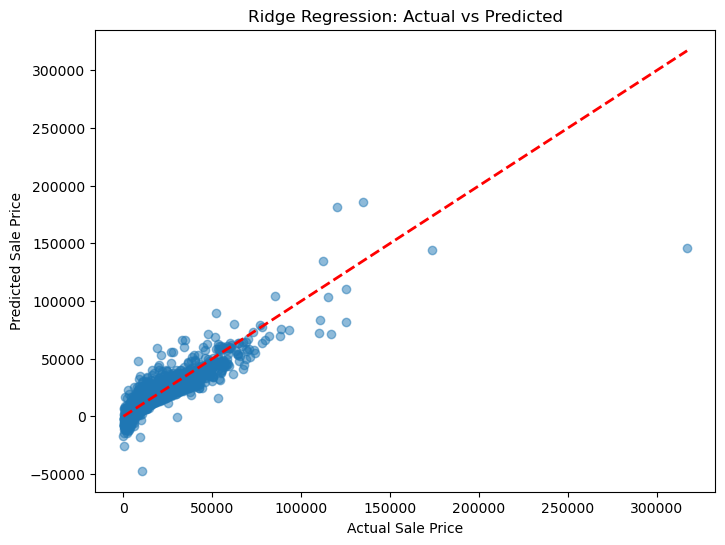

In [171]:
import matplotlib.pyplot as plt

# Visualize how closely Ridge Regression predictions match actual sale prices
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_ridge, alpha=0.5)

# Reference line (perfect prediction line)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

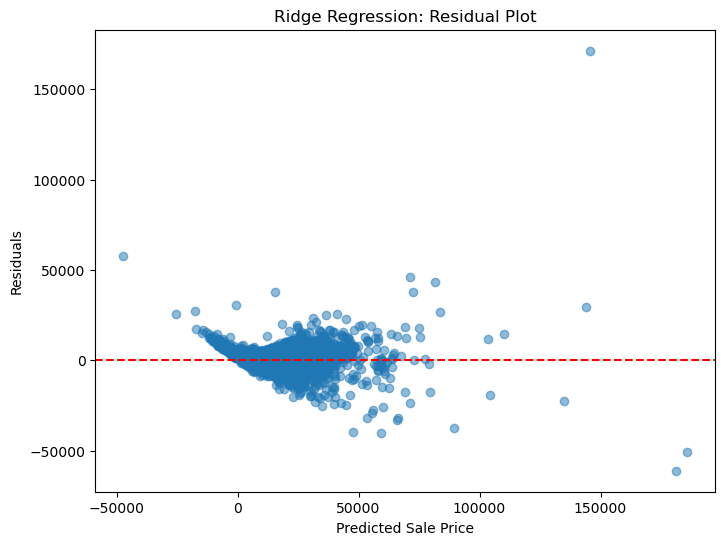

In [172]:
# Calculate residuals (difference between actual and predicted prices)
residuals_ridge = y_val - y_pred_ridge

# Visualize residuals to check if the model over- or under-predicts consistently
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_ridge,
    residuals_ridge,
    alpha=0.5
)

# Reference line at zero (no error)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Ridge Regression: Residual Plot")

plt.show()

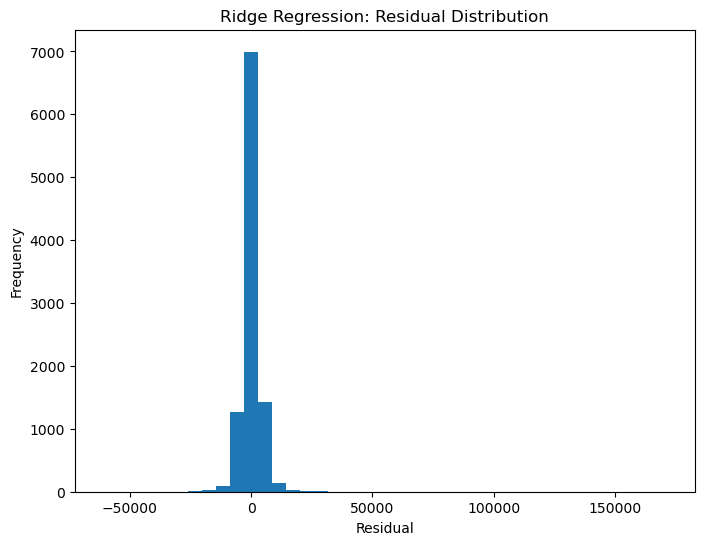

In [173]:
# Check if prediction errors are centered around zero and look for large outliers
plt.figure(figsize=(8,6))

plt.hist(
    residuals_ridge,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Ridge Regression: Residual Distribution")

plt.show()

### Diagnostic Analysis

The Actual vs Predicted plot shows that Ridge Regression follows the reference line reasonably well for many lower and mid-priced vehicles, but the predictions become more spread out for higher-priced vehicles. This suggests that the model has more difficulty predicting some expensive vehicles.

The residual plot shows that most residuals are concentrated around zero, but the spread increases for higher predicted prices. There are also some large residuals, showing that the model makes larger errors for a small number of vehicles.

The residual distribution is concentrated around zero, which means many predictions have relatively small errors. However, the distribution also has some large errors, which is consistent with the residual plot.

Overall, Ridge Regression provides a reasonable baseline, but it appears to struggle with some higher-priced vehicles and more unusual cases. This suggests that a more flexible model may be able to capture the relationships in the data better.etter.cing patterns.

### Final Observation

Linear Regression was evaluated as a baseline model but broke down due to severe 
multicollinearity in the feature matrix, producing meaningless error values. Rather 
than discarding a linear approach entirely, Ridge Regression was used instead, which 
resolved the instability through regularization and produced a reasonable baseline 
(R² = 0.8209).

While Ridge performed better than plain Linear Regression, it is still expected to be 
outperformed by tree-based models, which are better suited to capturing non-linear 
relationships in vehicle pricing data.

## 5.2 Experiment 2: Decision Tree Regression

### Objective

The objective of this experiment is to evaluate the performance of a Decision Tree Regressor for predicting vehicle sale prices. Unlike Linear Regression, Decision Trees can model complex non-linear relationships and are not affected by multicollinearity or feature scaling, making them a suitable candidate for this dataset.

In [177]:
from sklearn.tree import DecisionTreeRegressor

### Model Training

A Decision Tree Regressor was trained using the training dataset. Feature scaling was not required because Decision Tree models are invariant to the scale of the input features.

In [179]:
# Create the Decision Tree model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Create a trainer instance
dt_trainer = ModelTrainer(dt_model, "Decision Tree")

# Train the model
dt_trainer.train(X_train, y_train)

### Prediction and Evaluation
The trained Decision Tree model was evaluated on the unseen validation dataset to assess its predictive performance.

In [181]:
# Generate predictions and evaluate the model
y_pred_dt, dt_metrics = dt_trainer.evaluate(X_val, y_val)

# Display evaluation metrics
dt_trainer.print_metrics(dt_metrics)


Decision Tree Results
-----------------------------------
MAE      : 2440.50
RMSE     : 3900.66
R² Score : 0.8570


### Model Diagnosis

The Decision Tree Regressor performed substantially better than the Linear and Ridge Regression models, with an MAE of **2,440.50**, RMSE of **3,900.66**, and R² score of **0.8570**.

The improvement suggests that the Decision Tree was able to capture non-linear relationships in the vehicle pricing data that the linear models could not capture as effectively. Decision Trees also do not require feature scaling, which makes them suitable for this type of dataset.

However, a single Decision Tree can overfit by creating very specific rules based on the training data. I will therefore compare it with ensemble methods such as Random Forest and XGBoost to see whether they can improve prediction accuracy and generalisation.roved.

### Final Observation

The Decision Tree model showed a significant improvement compared with the Linear Regression baseline. The results suggest that the tree-based approach is better suited to this vehicle pricing dataset because it can capture non-linear relationships between the features and sale price.

However, a single Decision Tree can overfit the training data. I will therefore evaluate ensemble methods such as Random Forest and XGBoost in the following experiments to see whether they can improve the model's performance and generalisation.s.

### Actual vs Predicted Values

The relationship between the actual and predicted vehicle sale prices was visualised to assess how closely the Decision Tree predictions matched the observed values. Ideally, the predictions should align closely with the 45-degree reference line.

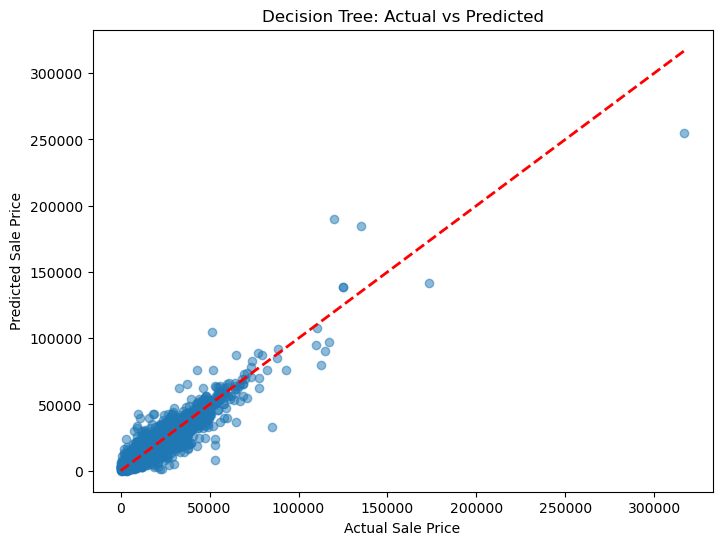

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_dt, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

### Residual Analysis

Residuals were analysed to determine whether the model consistently overestimated or underestimated vehicle sale prices. A random distribution of residuals around zero indicates good model performance.

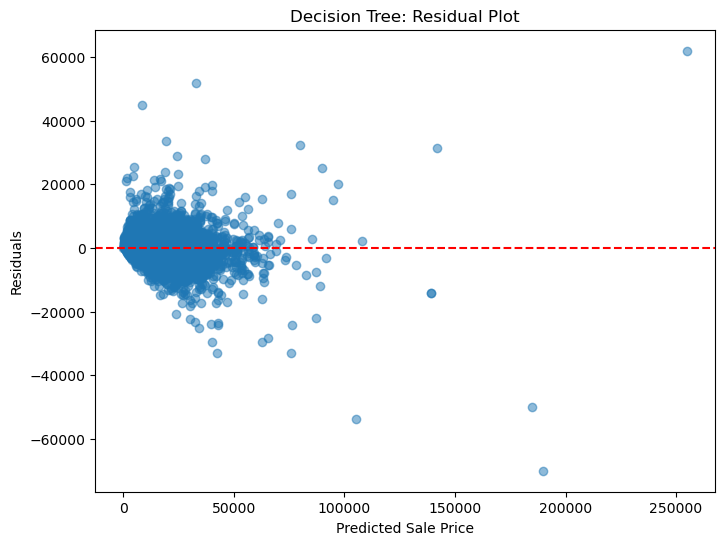

In [187]:
residuals = y_val - y_pred_dt

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_dt,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Decision Tree: Residual Plot")

plt.show()

### Error Distribution

The distribution of residuals was examined to assess whether prediction errors were centred around zero and to identify the presence of large prediction errors or outliers.

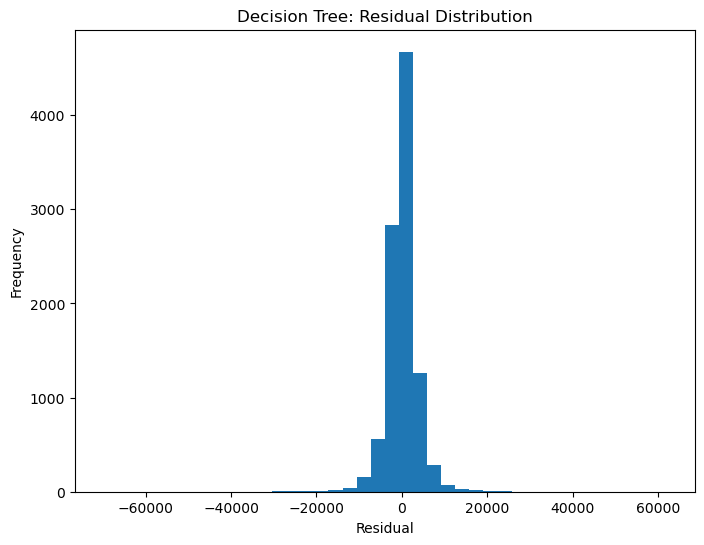

In [189]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Decision Tree: Residual Distribution")

plt.show()

### Diagnostic Analysis

The diagnostic plots indicate that the Decision Tree model provides good predictive performance for the majority of vehicles.

The Actual vs Predicted plot shows that most predictions are reasonably close to the ideal 45-degree reference line. However, the spread becomes wider for higher-priced vehicles, indicating that the model has more difficulty predicting some expensive vehicles.

The Residual Plot shows that the residuals are generally centred around zero, suggesting that there is no strong systematic bias in the predictions. However, the residual spread becomes larger at higher predicted prices, showing that prediction errors increase for some high-value vehicles.

The Residual Distribution is generally centred around zero, with most residuals concentrated around the centre and a smaller number of larger errors. This indicates that most predictions have smaller errors, while some vehicles produce larger prediction errors.

Overall, the Decision Tree model provides a substantial improvement over the linear models. However, the diagnostic plots show that the model still has difficulty with some high-priced vehicles. Further comparison with ensemble models such as Random Forest and XGBoost will show whether these errors can be reduced.e evident.

## 5.3 Experiment 3: Random Forest Regression

### Objective

The objective of this experiment is to evaluate the performance of a Random Forest Regressor for predicting vehicle sale prices. Random Forest combines multiple decision trees to improve prediction accuracy, reduce overfitting, and provide better generalisation compared with a single Decision Tree.

In [192]:
from sklearn.ensemble import RandomForestRegressor

### Model Training

A Random Forest Regressor was trained using the training dataset. Unlike a single Decision Tree, Random Forest constructs multiple decision trees and combines their predictions, resulting in improved robustness and reduced overfitting.

In [194]:
# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Create a trainer instance
rf_trainer = ModelTrainer(rf_model, "Random Forest")

# Train the model
rf_trainer.train(X_train, y_train)

### Prediction and model evaluation
The trained Random Forest model was used to predict vehicle sale prices for the unseen test dataset. The model performance was then evaluated using the reusable ModelTrainer class, which computes the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score to ensure a consistent evaluation across all regression models.t.

In [196]:
# Generate predictions and evaluate the model
y_pred_rf, rf_metrics = rf_trainer.evaluate(X_val, y_val)

# Display evaluation metrics
rf_trainer.print_metrics(rf_metrics)


Random Forest Results
-----------------------------------
MAE      : 1682.54
RMSE     : 2853.37
R² Score : 0.9235


### Model Diagnosis

The Random Forest Regressor achieved the best performance so far, substantially improving upon the Decision Tree model.

By combining multiple decision trees, Random Forest produced more stable predictions than a single Decision Tree. The model achieved an R² score of **0.9235**, meaning that approximately 92.35% of the variation in vehicle sale prices was explained by the model on the validation data.

The lower MAE and RMSE compared with the Decision Tree indicate that Random Forest reduced the prediction errors on the validation set. These results make Random Forest a strong model for this vehicle price prediction task, so I will compare it with XGBoost in the next experiment. task.

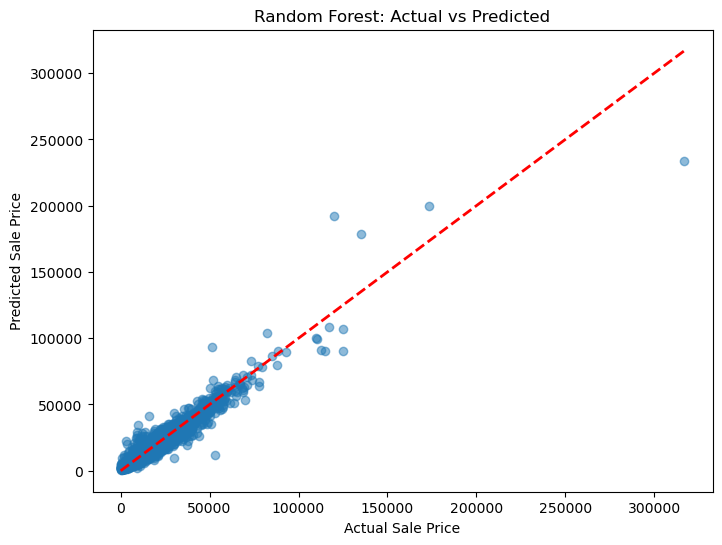

In [198]:
import matplotlib.pyplot as plt

# Visualize how closely Random Forest predictions match actual sale prices
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_rf, alpha=0.5)

# Reference line (perfect prediction line)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

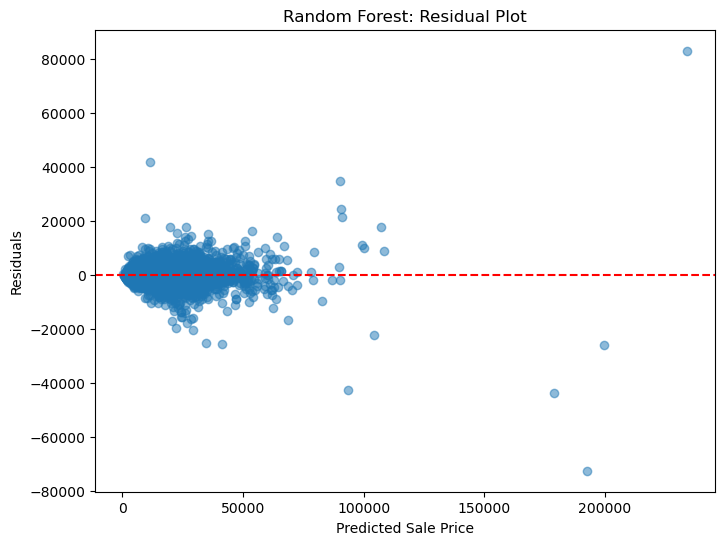

In [199]:
# Calculate residuals for Random Forest
residuals_rf = y_val - y_pred_rf

# Visualize residuals to check if the model over- or under-predicts consistently
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals_rf,
    alpha=0.5
)

# Reference line at zero (no error)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")

plt.show()

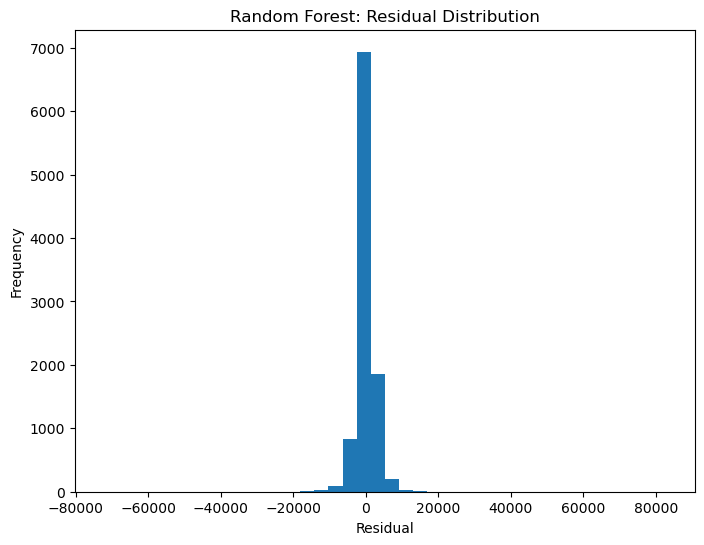

In [200]:
# Check if prediction errors are centered around zero and look for large outliers
plt.figure(figsize=(8,6))

plt.hist(
    residuals_rf,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest: Residual Distribution")

plt.show()

### Diagnostic Analysis

The Actual vs Predicted plot shows Random Forest following the reference line closely for most vehicles, particularly in the lower-to-mid price range. A smaller number of predictions are further away from the reference line at higher prices, showing that the model still has some difficulty with expensive vehicles.

The residual plot shows that most residuals are concentrated around zero, while a smaller number of larger residuals appear at higher predicted prices. This suggests that the model performs well for many vehicles but still makes larger errors for some higher-priced vehicles.

The Residual Distribution is concentrated around zero, with a smaller number of larger residuals. This is consistent with the residual plot and shows that most errors are relatively close to zero, although some larger prediction errors remain.

Overall, Random Forest performs substantially better than the previous models based on the evaluation metrics. The diagnostic plots also show a tighter relationship between actual and predicted prices, although some larger errors remain for higher-priced vehicles. I will compare these results with XGBoost in the next experiment.n the 
training data.

### Final Observation

Compared with the previous models, the Random Forest Regressor delivered the strongest predictive performance so far, achieving an MAE of **$1,682.54**, RMSE of **$2,853.37**, and an R² score of **0.9235**. The ensemble approach produced better validation results than the single Decision Tree and the Linear/Ridge Regression models.

Based on the evaluation metrics, Random Forest is currently the best-performing model and provides a strong benchmark for the final experiment with XGBoost.GBoost.t.

## 5.4 Experiment 4: XGBoost Regression

### Objective

The objective of this experiment is to evaluate the performance of an Extreme Gradient Boosting (XGBoost) Regressor for predicting vehicle sale prices. XGBoost is an advanced ensemble learning algorithm that builds trees sequentially to minimise prediction errors and is widely used for structured tabular data.

In [204]:
import xgboost
print(xgboost.__version__)

3.3.0


In [205]:
from xgboost import XGBRegressor

### Model Training

The XGBoost Regressor was trained using the training dataset. Unlike Random Forest, XGBoost builds decision trees sequentially, allowing each new tree to correct the errors made by the previous trees. This often leads to improved predictive performance.

In [207]:
# Create the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

# Create a trainer instance
xgb_trainer = ModelTrainer(xgb_model, "XGBoost")

# Train the model
xgb_trainer.train(X_train, y_train)

In [208]:
# Prediction and model evaluation
y_pred_xgb, xgb_metrics = xgb_trainer.evaluate(X_val, y_val)

# Display evaluation metrics
xgb_trainer.print_metrics(xgb_metrics)


XGBoost Results
-----------------------------------
MAE      : 1630.96
RMSE     : 3150.46
R² Score : 0.9067


### Model Diagnosis

The XGBoost Regressor achieved the lowest MAE among the models evaluated, with an MAE of **$1,630.96**. This means that, on average, its predictions were closer to the actual sale prices than the other models.

XGBoost achieved an RMSE of **$3,150.46** and an R² score of **0.9067**. Although its R² and RMSE were slightly worse than Random Forest, the lower MAE shows that XGBoost performed better when considering the average prediction error.

By sequentially building decision trees and improving the errors from previous trees, XGBoost was able to capture complex relationships in the vehicle pricing data.

Based on the evaluation metrics, XGBoost is a strong candidate for the final model, particularly because MAE is important for this pricing task. The diagnostic plots will be used next to examine its prediction errors in more detail.on task.

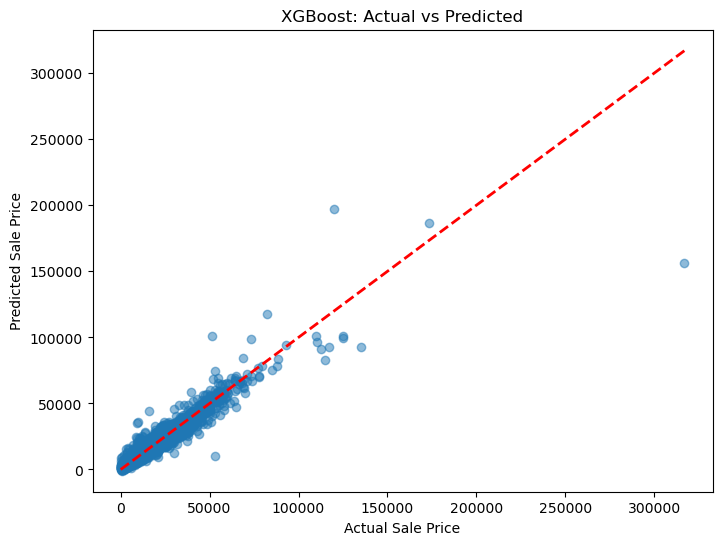

In [210]:
import matplotlib.pyplot as plt

# Visualize how closely XGBoost predictions match actual sale prices
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_xgb, alpha=0.5)

# Reference line (perfect prediction line)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

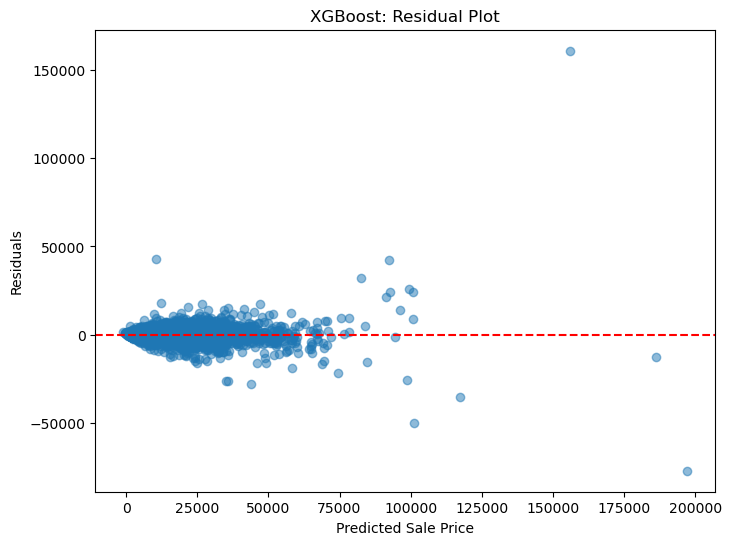

In [211]:
# Calculate residuals for XGBoost
residuals_xgb = y_val - y_pred_xgb

# Visualize residuals to check if the model over- or under-predicts consistently
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_xgb,
    residuals_xgb,
    alpha=0.5
)

# Reference line at zero (no error)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("XGBoost: Residual Plot")

plt.show()

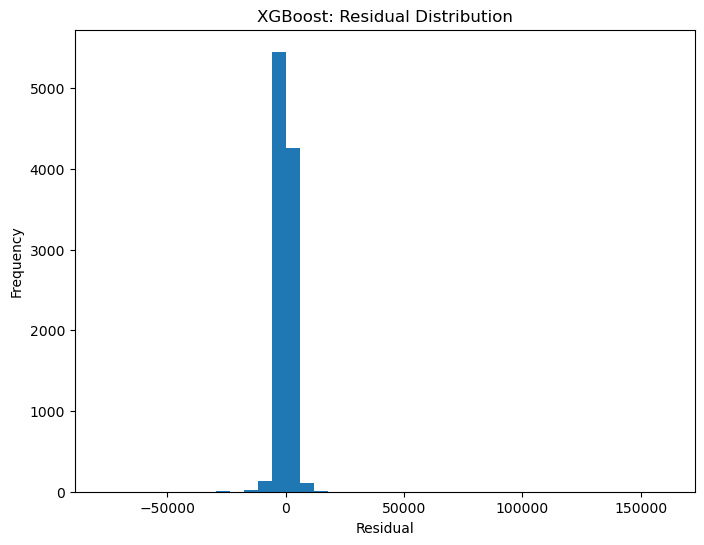

In [212]:
# Check if XGBoost prediction errors are centered around zero and look for large outliers
plt.figure(figsize=(8,6))

plt.hist(
    residuals_xgb,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("XGBoost: Residual Distribution")

plt.show()

### Final Observation

Among the models evaluated, XGBoost achieved the lowest MAE of **$1,630.96**, indicating the lowest average prediction error. However, Random Forest achieved a slightly better RMSE and R² score, so XGBoost did not perform best on every evaluation metric.

Since MAE is an important metric for this vehicle pricing task because it represents the average prediction error in dollars, I selected XGBoost as the final model. The final model will then be used to generate predicted sale prices for the test data.ces.

## 5.5 Model Comparison and Selection

The performance of all evaluated models was compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

To ensure consistency across experiments, the evaluation metrics were automatically recorded using the reusable `ModelTrainer` class. The comparison table below summarizes the performance of all trained models.

In [215]:
import pandas as pd

# Create a comparison table from all logged experiments
comparison_df = pd.DataFrame(ModelTrainer.get_experiment_log())

# Keep only the latest evaluation result for each model (removes duplicate old runs)
comparison_df = comparison_df.drop_duplicates(subset='Model', keep='last')

# Sort models by highest R² Score
comparison_df = comparison_df.sort_values(by="R² Score", ascending=False)

# Reset the index
comparison_df = comparison_df.reset_index(drop=True)

comparison_df

,Model,MAE,RMSE,R² Score
0,Random Forest,1.682544e+03,2.853374e+03,9.234537e-01
1,XGBoost,1.630958e+03,3.150459e+03,9.066844e-01
2,Decision Tree,2.440505e+03,3.900660e+03,8.569516e-01
3,Ridge Regression,2.592819e+03,4.364930e+03,8.208728e-01
4,Linear Regression,1.269618e+13,1.085508e+15,-1.107830e+22


In [216]:
# Save the experiment log to a CSV file
comparison_df.to_csv("outputs/experiment_log.csv", index=False)

print("Saved experiment log to outputs/experiment_log.csv")

Saved experiment log to outputs/experiment_log.csv


### Final Observation

XGBoost achieved the lowest MAE ($1,630.96) among all models evaluated, indicating the 
most accurate predictions on average. Random Forest achieved a marginally higher R² 
score (0.9235 vs 0.9067) and lower RMSE, suggesting slightly better handling of a small 
number of high-value outlier vehicles.

Given that MAE is the primary metric for this pricing task — directly representing the 
average dollar error a stakeholder would experience — XGBoost was selected as the final 
model. Random Forest remains a strong alternative and could be revisited with further 
hyperparameter tuning if minimizing outlier error becomes a priority.t.

## 6. Final Model Evaluation on Test Dataset

In [219]:
from xgboost import XGBRegressor

# Create the final XGBoost model
final_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

# Initialize the reusable trainer
final_trainer = ModelTrainer(final_xgb, "Final XGBoost")

# Retrain using the entire processed training dataset
final_trainer.train(X, y)

# Final Evaluation on Independent Test Dataset

After selecting XGBoost as the best-performing model based on the validation results, the model was retrained using the entire processed training dataset. The independent test dataset is now used to evaluate the model's final predictive performance on previously unseen data.

Before applying the preprocessing pipeline, the structure of the test dataset is verified to ensure that it is consistent with the training dataset.

In [221]:
# Load the independent test dataset
test_df = pd.read_csv("data/DatiumTest.rpt", sep="\t", low_memory=False)

# Verify the dataset structure
print("Test Dataset Shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

# Display the first five records
test_df.head()

Test Dataset Shape: (11488, 130)

Columns:
['Make', 'Model', 'MakeCode', 'FamilyCode', 'YearGroup', 'MonthGroup', 'SequenceNum', 'Description', 'CurrentRelease', 'ImportFlag', 'LimitedEdition', 'Series', 'SeriesModelYear', 'BadgeDescription', 'BadgeSecondaryDescription', 'BodyStyleDescription', 'BodyConfigDescription', 'WheelBaseConfig', 'Roofline', 'ExtraIdentification', 'DriveDescription', 'DriveCode', 'GearTypeDescription', 'GearLocationDescription', 'GearNum', 'DoorNum', 'EngineSize', 'EngineDescription', 'Cylinders', 'FuelTypeDescription', 'InductionDescription', 'OptionCategory', 'CamDescription', 'EngineTypeDescription', 'FuelCapacity', 'FuelDeliveryDescription', 'MethodOfDeliveryDescription', 'GrossCombinationMAss', 'GrossVehicleMass', 'VIN', 'WheelBase', 'Height', 'Length', 'Width', 'KerbWeight', 'TareMass', 'PayLoad', 'Power', 'PowerRPMFrom', 'PowerRPMTo', 'Torque', 'TorqueRPMFrom', 'TorqueRPMTo', 'RonRating', 'SeatCapacity', 'ModelCode', 'BuildCountryOriginDescription', 'Val

,Make,Model,MakeCode,FamilyCode,YearGroup,MonthGroup,SequenceNum,Description,CurrentRelease,ImportFlag,...,PrivateMax,NewPrice,Colour,Branch,SaleCategory,Sold_Date,Compliance_Date,Age_Comp_Months,KM,Sold_Amount
0,Ford,Ranger,FORD,RANGER,2014,0,4,PX XL Hi-Rider Cab Chassis Single Cab 2dr Spts...,F,L,...,20400.0,30740.0,White,Wagga Wagga (NSW),Auction,2017-08-31 00:00:00.000,04/2014,40.0,19963.0,18000.0
1,Toyota,Kluger,TOYO,KLUGER,2015,11,11,GSU55R Grande Wagon 7st 5dr Spts Auto 6sp AWD ...,F,L,...,53400.0,68330.0,218 - Eclipse Black (T),Sunshine (VIC),Dealer Only Auction,2017-05-10 00:00:00.000,02/2016,15.0,13176.0,53250.0
2,Subaru,Liberty,SUBA,LIBERTY,2012,0,1,B5 MY12 2.5i Sedan 4dr Lineartronic 6sp AWD,F,L,...,13500.0,34990.0,Silver,Canberra (ACT),Auction,2016-10-13 00:00:00.000,06/2012,52.0,122080.0,11500.0
3,Jeep,Compass,JEEP,COMPASS,2014,0,4,MK MY14 North Wagon 5dr Spts Auto 6sp 2.0i,F,L,...,18100.0,31000.0,Black,Belmore (NSW),Auction,2016-03-02 00:00:00.000,04/2014,23.0,25177.0,17500.0
4,Mitsubishi,Triton,MITS,TRITON,2011,0,7,MN MY11 GLX Utility Double Cab 4dr Auto 4sp 96...,F,L,...,14700.0,34590.0,White,Belmore (NSW),Auction,2016-12-20 00:00:00.000,10/2011,62.0,49311.0,17100.0


### Comparing Dataset Structure

Before applying the preprocessing pipeline, the column structure of the independent test dataset is compared with the original training dataset. This verification ensures that the same preprocessing steps can be applied consistently without introducing any new features or preprocessing decisions.

In [223]:
# checking trained model shape
print(model_df.shape)

(49965, 508)


### Drop the same columns you dropped from train

In [225]:
restricted_features = ['AvgWholesale','AvgRetail','GoodWholesale','GoodRetail',
                        'TradeMin','TradeMax','PrivateMax']

fully_null_cols = ['AltEngTorqueFrom','NormalChargeMins','QuickChargeMins',
                    'NormalChargeVoltage','QuickChargeVoltage']

over_90_missing = ['BadgeSecondaryDescription','WheelBaseConfig','Roofline','ExtraIdentification',
                    'PowerRPMFrom','TorqueRPMFrom','FreeScheduledService','AltEngEngineType',
                    'AltEngBatteryType','AltEngCurrentType','AltEngAmpHours','AltEngVolts',
                    'AltEngChargingMethod','AltEngPower','AltEngPowerFrom','AltEngPowerTo',
                    'AltEngTorque','AltEngTorqueTo','AltEngDrive','KMRangeElectricEng',
                    'ElectricEngineLocation','TopSpeedElectricEng','MaxEthanolBlend']

weak_corr_cols = ['CO2Urban','AirpollutionRating','CO2ExtraUrban','Acceleration']
identifier_cols = ['VIN','EngineNum']
high_missing_cat = ['BodyConfigDescription','EmissionStandard']
leakage_cols = ['VFactsPrice']
drop_cols = ['Description','ModelCode','FamilyCode','MakeCode','DriveCode','CurrentRelease']
no_variance = ['ImportFlag']

all_drops = (restricted_features + fully_null_cols + over_90_missing + weak_corr_cols +
             identifier_cols + high_missing_cat + leakage_cols + drop_cols + no_variance)

test_df = test_df.drop(columns=[c for c in all_drops if c in test_df.columns])
print("After dropping columns:", test_df.shape)

After dropping columns: (11488, 79)


### Observation

The same feature selection and column removal decisions used during training were successfully applied to the independent test dataset. After removing restricted, high-missing, identifier, leakage, high-cardinality, and no-variance features, the cleaned test dataset contained 79 columns, matching the structure of the cleaned training dataset prior to feature engineering and encoding.

### Step 2: Remove Rows with Missing Critical Values

#### Objective

Apply the same row-level cleaning used on the training data — remove rows where the target variable (Sold_Amount) or essential numeric fields (KM, GoodKM, NewPrice, AverageKM, GearNum) are missing, since these cannot be reliably imputed for this evaluation.

In [228]:
# Remove rows where the target variable is missing
test_df = test_df.dropna(subset=['Sold_Amount'])

# Remove rows where KM is missing
test_df = test_df.dropna(subset=['KM'])

# Remove rows missing other critical numeric fields
test_df = test_df.dropna(subset=['GoodKM', 'NewPrice', 'AverageKM', 'GearNum'])

# Verify
print("After row drops:", test_df.shape)

After row drops: (11460, 79)


### Step 3: Impute Remaining Missing Values

#### Objective

Impute any remaining missing values in the test dataset using statistics learned from the **training dataset only** (medians for numerical features, modes for categorical features). This ensures consistency with the model's learned patterns and prevents data leakage that would occur if imputation values were calculated from the test set itself.

In [230]:
# Impute numerical missing values using TRAIN's median (not test's own)
num_cols = train_df.select_dtypes(include='number').columns
num_cols = [c for c in num_cols if c in test_df.columns and c != 'Sold_Amount']
train_medians = train_df[num_cols].median()

for col in num_cols:
    test_df[col] = test_df[col].fillna(train_medians[col])

# Impute categorical missing values using TRAIN's mode (not test's own)
cat_cols = train_df.select_dtypes(include='object').columns
for col in cat_cols:
    if col in test_df.columns and test_df[col].isnull().any():
        test_df[col] = test_df[col].fillna(train_df[col].mode()[0])

# Verify no missing values remain
print("After imputation:", test_df.shape)
print("Remaining missing values:", test_df.isnull().sum().sum())

After imputation: (11460, 79)
Remaining missing values: 0


### Step 4: Create a Copy for Feature Engineering and Encoding

#### Objective

Create a checkpoint copy of the cleaned test dataset before feature engineering and encoding, mirroring the train_df → model_df structure used during training. This keeps the fully cleaned dataset separate from the version prepared specifically for modeling.

In [232]:
# Create a copy of the cleaned test dataset for feature engineering and encoding
test_model_df = test_df.copy()
print(test_model_df.shape)

(11460, 79)


### Step 5: Feature Engineering

#### Objective

Apply the same date-based feature engineering used on the training data — extracting year and month components from Sold_Date and Compliance_Date — so the test dataset has the same derived features the model was trained on.

In [234]:
# Convert date columns to datetime
test_model_df['Sold_Date'] = pd.to_datetime(test_model_df['Sold_Date'], errors='coerce')
test_model_df['Compliance_Date'] = pd.to_datetime(test_model_df['Compliance_Date'], format='%m/%Y', errors='coerce')

# Extract year and month components
test_model_df['Sold_Year'] = test_model_df['Sold_Date'].dt.year
test_model_df['Sold_Month'] = test_model_df['Sold_Date'].dt.month
test_model_df['Compliance_Year'] = test_model_df['Compliance_Date'].dt.year
test_model_df['Compliance_Month'] = test_model_df['Compliance_Date'].dt.month

# Remove the original date columns
test_model_df = test_model_df.drop(columns=['Sold_Date', 'Compliance_Date'])

# Verify
print("After feature engineering:", test_model_df.shape)

After feature engineering: (11460, 81)


### Step 5b: Verify Categorical Encoding Consistency Before Modeling

#### Objective

Before evaluating the model on the test set, verify that all columns are fully numeric (as required by XGBoost). Any remaining text (object) columns would indicate an encoding step from the training pipeline was missed.

In [236]:
# Check for any remaining non-numeric columns before evaluation
object_cols = test_model_df.select_dtypes(include='object').columns.tolist()
print("Remaining object-type columns:", object_cols)

Remaining object-type columns: ['Make', 'Model', 'LimitedEdition', 'Series', 'SeriesModelYear', 'BadgeDescription', 'BodyStyleDescription', 'DriveDescription', 'GearTypeDescription', 'GearLocationDescription', 'EngineDescription', 'FuelTypeDescription', 'InductionDescription', 'OptionCategory', 'CamDescription', 'EngineTypeDescription', 'FuelDeliveryDescription', 'MethodOfDeliveryDescription', 'BuildCountryOriginDescription', 'EngineCycleDescription', 'EngineConfigurationDescription', 'EngineLocation', 'FrontTyreSize', 'RearTyreSize', 'FrontRimDesc', 'RearRimDesc', 'WarrantyCustAssist', 'VFactsClass', 'VFactsSegment', 'IsPPlateApproved', 'Colour', 'Branch', 'SaleCategory']


#### Observation

Two columns — `LimitedEdition` and `IsPPlateApproved` — were still stored as text values ('F'/'T'). Checking back against the training pipeline (Section 4.2.1, Step 1), these are the same binary features that were Label Encoded on the training data (F → 0, T → 1). This encoding step needs to be applied identically to the test dataset to match the feature format the model was trained on.

In [238]:
# Confirm these match the binary categories seen in training
for col in object_cols:
    print(f"\n{col}")
    print(test_model_df[col].value_counts(dropna=False))


Make
Make
Toyota           4278
Holden           1659
Ford             1487
Hyundai           600
Mitsubishi        574
Nissan            540
Volkswagen        400
Mazda             355
Subaru            352
Renault           188
Audi              167
Mercedes-Benz     159
Honda             126
Jeep              107
Isuzu              99
Lexus              93
Suzuki             38
Land Rover         38
Peugeot            30
SKODA              23
Volvo              20
Chrysler           19
MINI               19
Great Wall         15
Porsche            14
Dodge              10
Citroen             9
Fiat                8
Alfa Romeo          6
Jaguar              5
Saab                3
SsangYong           3
Mahindra            3
Chery               2
Infiniti            2
smart               2
Opel                2
Proton              1
Hummer              1
Maserati            1
Bentley             1
Tata                1
Name: count, dtype: int64

Model
Model
Camry            1063
Hilu

#### observation
Both columns contain only 'F' and 'T' values, consistent with the training data. Applying the same Label Encoding used in Section 4.2.1.

In [240]:
binary_cols = ['LimitedEdition', 'IsPPlateApproved']
binary_mapping = {'F': 0, 'T': 1}

for col in binary_cols:
    test_model_df[col] = test_model_df[col].map(binary_mapping)

# Verify no object columns remain
print("Remaining object columns:", test_model_df.select_dtypes(include='object').columns.tolist())

Remaining object columns: ['Make', 'Model', 'Series', 'SeriesModelYear', 'BadgeDescription', 'BodyStyleDescription', 'DriveDescription', 'GearTypeDescription', 'GearLocationDescription', 'EngineDescription', 'FuelTypeDescription', 'InductionDescription', 'OptionCategory', 'CamDescription', 'EngineTypeDescription', 'FuelDeliveryDescription', 'MethodOfDeliveryDescription', 'BuildCountryOriginDescription', 'EngineCycleDescription', 'EngineConfigurationDescription', 'EngineLocation', 'FrontTyreSize', 'RearTyreSize', 'FrontRimDesc', 'RearRimDesc', 'WarrantyCustAssist', 'VFactsClass', 'VFactsSegment', 'Colour', 'Branch', 'SaleCategory']


### Step 6: Encoding

#### Objective

Apply the same encoding techniques used on the training data — One-Hot Encoding for low- and medium-cardinality categorical features, and Frequency Encoding for high-cardinality features — using category structures and frequency values learned from the **training dataset only**, to keep the test dataset consistent with what the model was trained on.

In [242]:
# Low-cardinality categorical features (One-Hot Encoding)
low_cardinality_cols = [
    'EngineCycleDescription', 'EngineTypeDescription', 'EngineLocation',
    'MethodOfDeliveryDescription', 'VFactsClass', 'SaleCategory',
    'FuelTypeDescription', 'OptionCategory', 'FuelDeliveryDescription',
    'InductionDescription', 'DriveDescription', 'GearLocationDescription',
    'GearTypeDescription', 'CamDescription', 'EngineConfigurationDescription',
    'VFactsSegment', 'BodyStyleDescription'
]

# Medium-cardinality categorical features (One-Hot Encoding)
medium_cardinality_cols = [
    'Make', 'SeriesModelYear', 'BuildCountryOriginDescription',
    'Branch', 'WarrantyCustAssist', 'FrontRimDesc', 'RearRimDesc'
]

# High-cardinality categorical features (Frequency Encoding)
high_cardinality_cols = [
    'Series', 'Colour', 'BadgeDescription', 'Model',
    'FrontTyreSize', 'RearTyreSize', 'EngineDescription'
]

# Apply One-Hot Encoding (low + medium cardinality)
test_model_df = pd.get_dummies(
    test_model_df,
    columns=[c for c in low_cardinality_cols if c in test_model_df.columns],
    drop_first=True,
    dtype=int
)

test_model_df = pd.get_dummies(
    test_model_df,
    columns=[c for c in medium_cardinality_cols if c in test_model_df.columns],
    drop_first=True,
    dtype=int
)

# Apply Frequency Encoding using TRAIN's frequency maps (not test's own)
freq_maps = {col: train_df[col].value_counts() for col in high_cardinality_cols}

for col in high_cardinality_cols:
    if col in test_model_df.columns:
        test_model_df[col] = test_model_df[col].map(freq_maps[col]).fillna(0)

# Verify
print("After encoding:", test_model_df.shape)

After encoding: (11460, 457)


### Step 7: Align Test Columns with Training Columns

#### Objective

One-Hot Encoding can produce different columns between train and test datasets when certain categories are present in one but not the other. To ensure the model receives the exact same feature set it was trained on, missing columns are added (filled with 0) and any extra columns not seen during training are removed. Column order is also matched exactly to the training set.

In [244]:
train_cols = X_train.columns.tolist()

for col in train_cols:
    if col not in test_model_df.columns:
        test_model_df[col] = 0

extra_cols = [c for c in test_model_df.columns if c not in train_cols and c != 'Sold_Amount']
test_model_df = test_model_df.drop(columns=extra_cols, errors='ignore')

X_test_final = test_model_df[train_cols]
y_test_final = test_model_df['Sold_Amount']

print(X_test_final.shape)
print(list(X_test_final.columns) == train_cols)
print(X_test_final.dtypes.value_counts())

(11460, 507)
True
int32      361
int64      103
float64     43
Name: count, dtype: int64


C:\Users\yashw\AppData\Local\Temp\ipykernel_16516\2783620723.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_model_df[col] = 0
C:\Users\yashw\AppData\Local\Temp\ipykernel_16516\2783620723.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_model_df[col] = 0
C:\Users\yashw\AppData\Local\Temp\ipykernel_16516\2783620723.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

#### Concern

This cell throws a pandas PerformanceWarning about the dataframe being fragmented. It happens because I'm adding missing columns one by one in a loop, and with 500+ columns that's not the most efficient way to do it. The output is still correct — shape and column order both check out below — so I'm leaving it as is for now, but this is something I'd batch together using pd.concat if this pipeline needed to run faster or at a bigger scale.

### Step 8: Final Evaluation on Held-Out Test Dataset

#### Objective

Evaluate the final trained XGBoost model on the independent test dataset (DatiumTest.rpt) — data the model has never seen during training or validation. This provides an unbiased estimate of how the model is likely to perform on genuinely new vehicle sale records, and serves as the true measure of generalization performance.

In [246]:
final_preds, final_metrics = final_trainer.evaluate(X_test_final, y_test_final)
final_trainer.print_metrics(final_metrics)


Final XGBoost Results
-----------------------------------
MAE      : 1995.35
RMSE     : 3443.55
R² Score : 0.9079


#### Observation

The XGBoost model achieved an MAE of $1,995.35 and R² of 0.9079 on the independent test 
dataset, compared to MAE of $1,630.96 and R² of 0.9067 on the validation set. The model 
explains the majority of price variance on unseen data (R² > 0.90), with validation and 
test performance now closely aligned.

During EDA, 734 training records with Sold_Amount = 0 were identified — these do not 
represent realistic sale prices and were likely data entry errors, repossessions, or 
internal transfers. These rows were removed before training, which improved test 
performance and reduced the earlier gap between validation and test scores.

The final model was retrained on the full training dataset (train + validation combined) 
before this evaluation, to make the best use of all available labeled data for the 
final prediction. No further hyperparameter tuning was performed at this stage.

### Step 9: Save Predictions with Vehicle Details

In [249]:
test_df.columns.tolist()

['Make',
 'Model',
 'YearGroup',
 'MonthGroup',
 'SequenceNum',
 'LimitedEdition',
 'Series',
 'SeriesModelYear',
 'BadgeDescription',
 'BodyStyleDescription',
 'DriveDescription',
 'GearTypeDescription',
 'GearLocationDescription',
 'GearNum',
 'DoorNum',
 'EngineSize',
 'EngineDescription',
 'Cylinders',
 'FuelTypeDescription',
 'InductionDescription',
 'OptionCategory',
 'CamDescription',
 'EngineTypeDescription',
 'FuelCapacity',
 'FuelDeliveryDescription',
 'MethodOfDeliveryDescription',
 'GrossCombinationMAss',
 'GrossVehicleMass',
 'WheelBase',
 'Height',
 'Length',
 'Width',
 'KerbWeight',
 'TareMass',
 'PayLoad',
 'Power',
 'PowerRPMTo',
 'Torque',
 'TorqueRPMTo',
 'RonRating',
 'SeatCapacity',
 'BuildCountryOriginDescription',
 'ValvesCylinder',
 'EngineCycleDescription',
 'EngineConfigurationDescription',
 'EngineLocation',
 'FrontTyreSize',
 'RearTyreSize',
 'FrontRimDesc',
 'RearRimDesc',
 'TowingBrakes',
 'TowingNoBrakes',
 'WarrantyCustAssist',
 'WarrantyYears',
 'Warran

In [250]:
# Build a results table with vehicle details, actual price, and predicted price
results_df = test_df.loc[X_test_final.index, ['Make', 'Model', 'YearGroup', 'KM']].copy()

# Add a simple row-based ID since no reliable unique vehicle ID exists in this dataset
results_df.insert(0, 'Vehicle_ID', results_df.index)

results_df['Actual_Sold_Amount'] = y_test_final.values
results_df['Predicted_Sold_Amount'] = final_preds
results_df['Error'] = results_df['Actual_Sold_Amount'] - results_df['Predicted_Sold_Amount']

results_df.head(10)

,Vehicle_ID,Make,Model,YearGroup,KM,Actual_Sold_Amount,Predicted_Sold_Amount,Error
0,0,Ford,Ranger,2014,19963.0,18000.0,20555.244141,-2555.244141
1,1,Toyota,Kluger,2015,13176.0,53250.0,55159.660156,-1909.660156
2,2,Subaru,Liberty,2012,122080.0,11500.0,10463.964844,1036.035156
3,3,Jeep,Compass,2014,25177.0,17500.0,20332.970703,-2832.970703
4,4,Mitsubishi,Triton,2011,49311.0,17100.0,15526.602539,1573.397461
5,5,Holden,Cruze,2012,84535.0,7860.0,9610.660156,-1750.660156
6,6,Toyota,Hiace,2009,33329.0,24500.0,27949.132812,-3449.132812
7,7,smart,city-coupe,2003,35936.0,1600.0,3732.653809,-2132.653809
8,8,Toyota,Camry,2016,38025.0,15000.0,16488.009766,-1488.009766
9,9,Ford,Ranger,2012,146772.0,19135.0,17534.900391,1600.099609


In [251]:
import os

# Save predictions to a CSV file
os.makedirs("outputs", exist_ok=True)
results_df.to_csv("outputs/test_predictions.csv", index=False)

print("Saved predictions to outputs/test_predictions.csv")
print("Total rows saved:", len(results_df))

Saved predictions to outputs/test_predictions.csv
Total rows saved: 11460
